In [1]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  KAGGLE Cell 0 — setup, paths, config                                ║
# ║  Requires: your dataset added as input (default name below)          ║
# ║  Settings → Accelerator: GPU (T4/P100) · Persistence: Files only     ║
# ╚══════════════════════════════════════════════════════════════════════╝
import importlib, subprocess, sys, glob
if importlib.util.find_spec("optuna") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "optuna"])

import os, warnings, json, math
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.interpolate import RegularGridInterpolator
import joblib
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── INPUT (read-only): your uploaded dataset ─────────────────────────
# ★ If you named the dataset differently, edit DATASET_NAME only.
DATA = "/kaggle/input/datasets/amlanprateeknitr/region-data/region_data"
# the folder may or may not contain the top-level 'region_data' wrapper
if os.path.isdir(os.path.join(DATA, "region_data")):
    DATA = os.path.join(DATA, "region_data")
print(f"Input dataset : {DATA}")
print("Contents      :", sorted(os.listdir(DATA)))

CACHE_DIR_IN = os.path.join(DATA, "series_cache")   
# fix Kaggle's double-nesting
if os.path.isdir(os.path.join(CACHE_DIR_IN, "series_cache")):
    CACHE_DIR_IN = os.path.join(CACHE_DIR_IN, "series_cache")# READ-ONLY
ELEV_FILE    = (glob.glob(os.path.join(DATA, "elevation*.nc")) + [None])[0]
SHAPEFILE    = (glob.glob(os.path.join(DATA, "target_shapefile", "*.shp"))
                + glob.glob(os.path.join(DATA, "**", "*.shp"), recursive=True))[0]
PREV_BEST    = os.path.join(DATA, "optuna_best_params.json")  # colab insurance copy

assert os.path.isdir(CACHE_DIR_IN), f"series_cache not found in {DATA}"
assert ELEV_FILE, "elevation .nc not found in dataset"
print(f"Cache files   : {len(os.listdir(CACHE_DIR_IN))}")
print(f"Elevation     : {os.path.basename(ELEV_FILE)}")
print(f"Shapefile     : {os.path.basename(SHAPEFILE)}")

# ── OUTPUT (writable) ────────────────────────────────────────────────
OUT_DIR    = "/kaggle/working/region_downscaling_output"
MODEL_DIR  = f"{OUT_DIR}/models"
SCALER_DIR = f"{OUT_DIR}/scalers"
for d in [OUT_DIR, MODEL_DIR, SCALER_DIR]:
    os.makedirs(d, exist_ok=True)

# ── RESUME: restore previous run's outputs from input dataset ────────
# After a successful run, upload your region_downscaling_output/ folder
# back into your Kaggle dataset.  This block finds it and copies models,
# scalers, QM, and Optuna files into /kaggle/working/ so Cell 4 skips
# already-trained months automatically.
import shutil as _shutil
_restore_dirs = (
    glob.glob("/kaggle/input/**/region_downscaling_output", recursive=True)
    + glob.glob("/kaggle/input/**/models/mlp_m01.pth", recursive=True)
)
PREV_OUTPUT = None
for _p in _restore_dirs:
    _candidate = _p if os.path.isdir(_p) else os.path.dirname(os.path.dirname(_p))
    if os.path.isdir(os.path.join(_candidate, "models")):
        PREV_OUTPUT = _candidate; break

if PREV_OUTPUT and PREV_OUTPUT != OUT_DIR:
    _copied = 0
    for _root, _dirs, _files in os.walk(PREV_OUTPUT):
        for _f in _files:
            _src = os.path.join(_root, _f)
            _rel = os.path.relpath(_src, PREV_OUTPUT)
            _dst = os.path.join(OUT_DIR, _rel)
            if not os.path.exists(_dst):
                os.makedirs(os.path.dirname(_dst), exist_ok=True)
                _shutil.copy2(_src, _dst); _copied += 1
    print(f"✅ Restored {_copied} file(s) from previous run: {PREV_OUTPUT}")
else:
    print("ℹ No previous output found in input — will train from scratch")

MLP_DAILY_TR = f"{OUT_DIR}/mlp_daily_train_region.nc"
MLP_DAILY_TE = f"{OUT_DIR}/mlp_daily_test_region.nc"
BC_DAILY_TR  = f"{OUT_DIR}/bc_daily_train_region.nc"
BC_DAILY_TE  = f"{OUT_DIR}/bc_daily_test_region.nc"
QM_TF_PATH   = f"{OUT_DIR}/qm_daily_tf_region.npz"
BEST_PARAMS  = f"{OUT_DIR}/optuna_best_params.json"
OPTUNA_DB    = f"{OUT_DIR}/optuna_study.db"          # every trial persisted here

# ── FIXED CONFIG (identical to Colab) ────────────────────────────────
TRAIN_START, TRAIN_END = 1981, 2004
TEST_START,  TEST_END  = 2005, 2014
CHIRPS_FILL  = -9999.0
N_QUANT      = 100
Q_LEVELS     = np.linspace(0, 1, N_QUANT)
EPOCHS       = 300
N_FEATURES   = 6
MONTH_NAMES  = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP      = torch.cuda.is_available()

print(f"\nDevice: {DEVICE} (AMP={'on' if USE_AMP else 'off'})  |  "
      f"Train {TRAIN_START}-{TRAIN_END}  Test {TEST_START}-{TEST_END}")


Input dataset : /kaggle/input/datasets/amlanprateeknitr/region-data/region_data
Contents      : ['elevation_005deg_india.nc', 'optuna_best_params.json', 'optuna_trials_colab_session1.csv', 'series_cache', 'target_shapefile']
Cache files   : 68
Elevation     : elevation_005deg_india.nc
Shapefile     : target (1).shp
ℹ No previous output found in input — will train from scratch

Device: cuda (AMP=on)  |  Train 1981-2004  Test 2005-2014


✅ Window grid from chr_1981.nc: 174 × 317
   lat 23.775 → 32.425 | lon 72.575 → 88.375
✅ Region mask : 15,708 cells (Colab had 15,708 — should match)
✅ Static features (15708, 3) [lat, lon, elev] | elev 25–994 m


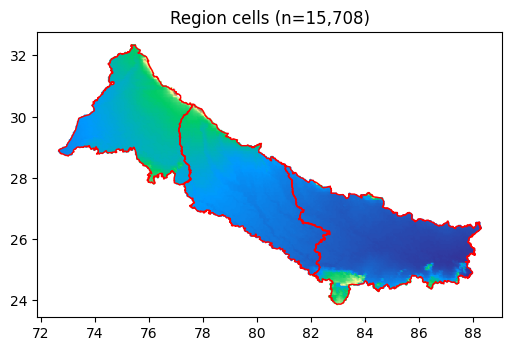

In [3]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  KAGGLE Cell 1 — region grid + mask + elevation                      ║
# ║  Grid comes from the cached regional files (window grid)             ║
# ╚══════════════════════════════════════════════════════════════════════╝

# Step 1: region window grid from one cached file
_sample = sorted(glob.glob(os.path.join(CACHE_DIR_IN, "chr_*.nc")))[0]
_d = xr.open_dataset(_sample)
reg_lats = _d["lat"].values
reg_lons = _d["lon"].values
_d.close()
if reg_lats[0] > reg_lats[-1]:
    reg_lats = reg_lats[::-1]
nr_lat, nr_lon = len(reg_lats), len(reg_lons)
print(f"✅ Window grid from {os.path.basename(_sample)}: {nr_lat} × {nr_lon}")
print(f"   lat {reg_lats[0]:.3f} → {reg_lats[-1]:.3f} | lon {reg_lons[0]:.3f} → {reg_lons[-1]:.3f}")

# Step 2: shapefile mask on the window grid (same method as Colab)
gdf = gpd.read_file(SHAPEFILE)
if gdf.crs is None:
    gdf = gdf.set_crs(epsg=4326)
elif gdf.crs.to_epsg() != 4326:
    gdf = gdf.to_crs(epsg=4326)
region_geom = gdf.union_all() if hasattr(gdf, 'union_all') else gdf.unary_union

lon_g, lat_g = np.meshgrid(reg_lons, reg_lats)
try:
    from shapely import contains_xy
    region_mask = contains_xy(region_geom, lon_g.ravel(), lat_g.ravel()).reshape(lon_g.shape)
except Exception:
    from shapely.vectorized import contains
    region_mask = contains(region_geom, lon_g.ravel(), lat_g.ravel()).reshape(lon_g.shape)

n_region = int(region_mask.sum())
assert n_region > 0, "0 cells inside shapefile — check CRS / files"
flat_idx = np.where(region_mask.ravel())[0]
ii_loc, jj_loc = np.unravel_index(flat_idx, (nr_lat, nr_lon))
print(f"✅ Region mask : {n_region:,} cells (Colab had 15,708 — should match)")

# Step 3: elevation onto region cells
ds_elev   = xr.open_dataset(ELEV_FILE)
e_lats    = ds_elev["lat"].values if "lat" in ds_elev.coords else ds_elev["latitude"].values
e_lons    = ds_elev["lon"].values if "lon" in ds_elev.coords else ds_elev["longitude"].values
elev_data = np.nan_to_num(ds_elev["elevation"].values.astype(np.float32), nan=0.0)
ds_elev.close()
if e_lats[0] > e_lats[-1]:
    e_lats = e_lats[::-1]; elev_data = elev_data[::-1, :]
interp_elev = RegularGridInterpolator((e_lats, e_lons), elev_data,
                                       method='linear', bounds_error=False, fill_value=0.0)
elev_reg = interp_elev(np.column_stack(
    [reg_lats[ii_loc], reg_lons[jj_loc]])).astype(np.float32)

STATIC_COLS = np.column_stack([
    reg_lats[ii_loc], reg_lons[jj_loc], elev_reg]).astype(np.float32)
print(f"✅ Static features {STATIC_COLS.shape} [lat, lon, elev] | "
      f"elev {elev_reg.min():.0f}–{elev_reg.max():.0f} m")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(reg_lons[jj_loc], reg_lats[ii_loc], s=1, c=elev_reg, cmap="terrain")
gdf.boundary.plot(ax=ax, color="red", lw=1)
ax.set_title(f"Region cells (n={n_region:,})"); plt.show()


In [4]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 2 — Optimized helpers: cached I/O, MLP factory, QM, trainer    ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ── one-time source-grid → India-cell index mapping ──────────────────
# ── per-YEAR cache: READ-ONLY regional .nc files from the dataset ───
_YEAR_CACHE = {}
def load_gcm_month(years, month):
    data_list, doy_list, date_list = [], [], []
    for yr in years:
        r = _get_year("gcm", yr)
        if r is None: continue
        data, dates, doys = r
        m_mask = dates.month == month
        if not m_mask.any(): continue
        data_list.append(data[m_mask])
        doy_list.append(doys[m_mask])
        date_list.append(dates[m_mask])
    if not data_list:
        return None, None, None
    data  = np.concatenate(data_list, axis=0)
    doys  = np.concatenate(doy_list)
    dates = date_list[0].append(date_list[1:]) if len(date_list) > 1 else date_list[0]
    return data, doys, dates


def load_chirps_month(years, month):
    data_list = []
    for yr in years:
        r = _get_year("chr", yr)
        if r is None: continue
        data, dates, _ = r
        m_mask = dates.month == month
        if m_mask.any():
            data_list.append(data[m_mask])
    if not data_list:
        return None
    return np.concatenate(data_list, axis=0)
def _get_year(kind, yr):
    key = (kind, yr)
    if key in _YEAR_CACHE:
        return _YEAR_CACHE[key]
    ncp = os.path.join(CACHE_DIR_IN, f"{kind}_{yr}.nc")
    if not os.path.exists(ncp):
        _YEAR_CACHE[key] = None
        print(f"  ⚠ missing regional file: {kind}_{yr}.nc")
        return None
    dsc  = xr.open_dataset(ncp)
    t    = pd.to_datetime(dsc["time"].values)
    la   = dsc["lat"].values
    arr  = dsc["pr"].values.astype(np.float32)
    dsc.close()
    if la[0] > la[-1]:
        arr = arr[:, ::-1, :]
    data = arr[:, ii_loc, jj_loc]                       # (T_year, n_region)
    out  = (data, t, t.day_of_year.values.astype(np.int32))
    _YEAR_CACHE[key] = out
    return out

# ── feature builder (preallocated) ───────────────────────────────────
def build_X(gcm_days, doys):
    n_days  = len(doys)
    sin_d   = np.sin(2*np.pi*doys/365.25).astype(np.float32)
    cos_d   = np.cos(2*np.pi*doys/365.25).astype(np.float32)
    X = np.empty((n_days*n_region, N_FEATURES), dtype=np.float32)
    X[:, 0] = gcm_days.ravel()
    X[:, 1] = np.tile(STATIC_COLS[:, 0], n_days)
    X[:, 2] = np.tile(STATIC_COLS[:, 1], n_days)
    X[:, 3] = np.tile(STATIC_COLS[:, 2], n_days)
    X[:, 4] = np.repeat(sin_d, n_region)
    X[:, 5] = np.repeat(cos_d, n_region)
    return X

# ── configurable MLP ─────────────────────────────────────────────────
class MLPNet(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        act_map = {"gelu": nn.GELU, "leaky_relu": nn.LeakyReLU, "relu": nn.ReLU}
        act = act_map.get(cfg.get("activation", "relu"), nn.ReLU)
        layers, prev = [], N_FEATURES
        for h in cfg["hidden"]:
            layers.append(nn.Linear(prev, h))
            if cfg.get("batchnorm", True):
                layers.append(nn.BatchNorm1d(h))
            layers += [act(), nn.Dropout(cfg.get("dropout", 0.2))]
            prev = h
        layers += [nn.Linear(prev, 1), nn.Softplus()]   # smooth, keeps output >= 0
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(1)

DEFAULT_CFG = {"hidden": [128, 128, 64, 64], "dropout": 0.38625281322982374,
               "lr": 0.0023628864184236428,
               "weight_decay": 3.3347927286375814e-07, "batch_size": 32768,
               "activation": "leaky_relu", "batchnorm": False,
               "log_transform": False, "epochs": EPOCHS}

def load_cfg():
    if os.path.exists(BEST_PARAMS):
        with open(BEST_PARAMS) as f:
            c = json.load(f)
        c.setdefault("epochs", EPOCHS)
        print(f"✅ Using tuned config from Optuna: {c['hidden']} | lr={c['lr']:.2e} "
              f"| drop={c['dropout']:.2f} | log={c['log_transform']}")
        return c
    print("⚠ No optuna_best_params.json found — using DEFAULT_CFG")
    return dict(DEFAULT_CFG)

# ── inference helpers (handle log transform + AMP) ───────────────────
def _predict_mm(model, X_sc, log, bs):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X_sc), bs):
            xb = torch.from_numpy(X_sc[i:i+bs]).to(DEVICE, non_blocking=True)
            with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                p = model(xb)
            out.append(p.float().cpu().numpy())
    p = np.concatenate(out)
    return np.clip(np.expm1(p) if log else p, 0, None)

def _rmse_mm(model, X_sc, y_mm, log, bs):
    return float(np.sqrt(mean_squared_error(y_mm, _predict_mm(model, X_sc, log, bs))))

# ── shared trainer (used by Optuna AND final pipeline) ───────────────
def train_model(cfg, X_tr, y_tr, X_val=None, y_val=None,
                trial=None, epochs=None, patience=10):
    import optuna
    epochs = epochs or cfg.get("epochs", EPOCHS)
    log    = cfg.get("log_transform", True)
    bs     = cfg["batch_size"]

    model = MLPNet(cfg).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=cfg["lr"],
                             weight_decay=cfg.get("weight_decay", 0.0))
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit  = nn.MSELoss()
    gscale = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    y_in = np.log1p(y_tr).astype(np.float32) if log else y_tr.astype(np.float32)
    loader = DataLoader(
        TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_in)),
        batch_size=bs, shuffle=True, drop_last=True,
        pin_memory=USE_AMP, num_workers=2 if USE_AMP else 0,
        persistent_workers=USE_AMP)

    best_val, best_state, bad = np.inf, None, 0
    hist = {"train_loss": [], "val_rmse": []}
    for ep in range(1, epochs + 1):
        model.train(); run = 0.0
        for Xb, yb in loader:
            Xb = Xb.to(DEVICE, non_blocking=True); yb = yb.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                loss = crit(model(Xb), yb)
            gscale.scale(loss).backward(); gscale.step(opt); gscale.update()
            run += loss.item()
        sched.step()
        hist["train_loss"].append(run / max(1, len(loader)))

        if X_val is not None:
            vr = _rmse_mm(model, X_val, y_val, log, bs)
            hist["val_rmse"].append(vr)
            if trial is not None:
                trial.report(vr, ep)
                if trial.should_prune():
                    raise optuna.TrialPruned()
            if vr < best_val - 1e-4:
                best_val = vr; bad = 0
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            else:
                bad += 1
                if bad >= patience:
                    break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, (best_val if np.isfinite(best_val) else hist["train_loss"][-1]), hist

print(f"✅ Helpers ready (region: {n_region:,} cells).  Sanity check — January 1981...")
_g, _d, _ = load_gcm_month([1981], 1)
_c        = load_chirps_month([1981], 1)
print(f"   GCM   : {_g.shape}  min={np.nanmin(_g):.3f}  max={np.nanmax(_g):.3f}")
print(f"   CHIRPS: {_c.shape}  min={np.nanmin(_c):.3f}  max={np.nanmax(_c):.3f}")

# ── Quantile-mapping transfer functions (6 features unchanged) ───────
def fit_qmap_vectorized(obs_2d, his_2d):
    obs_clean = np.where(np.isnan(obs_2d), np.nanmedian(obs_2d, axis=0), obs_2d)
    his_clean = np.where(np.isnan(his_2d), np.nanmedian(his_2d, axis=0), his_2d)
    obs_q = np.quantile(obs_clean, Q_LEVELS, axis=0).T.astype(np.float32)
    his_q = np.quantile(his_clean, Q_LEVELS, axis=0).T.astype(np.float32)
    return obs_q, his_q

def apply_qmap_vectorized(his_2d, obs_q, his_q):
    bc = np.full_like(his_2d, np.nan)
    for k in range(n_region):
        vals = his_2d[:, k]; nm = np.isnan(vals)
        if np.any(~nm) and not np.isnan(his_q[k, 0]):
            _, uid = np.unique(his_q[k], return_index=True)
            bc[~nm, k] = np.clip(
                np.interp(vals[~nm], his_q[k, uid], obs_q[k, uid]), 0, None)
    return bc


✅ Helpers ready (region: 15,708 cells).  Sanity check — January 1981...
   GCM   : (31, 15708)  min=0.000  max=32.160
   CHIRPS: (31, 15708)  min=0.000  max=47.734


In [5]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  OPTUNA — COMMENTED OUT (best params already in DEFAULT_CFG above)   ║
# ║  Uncomment and run only if you want to re-tune hyperparameters.      ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ╔══════════════════════════════════════════════════════════════════════╗
# ║  KAGGLE Cell 3 — OPTUNA: July + January, 10 trials, RESUMABLE        ║
# ║  Every finished trial is saved to optuna_study.db instantly.         ║
# ║  Funnel architectures only · relu / gelu / leaky_relu                ║
# ╚══════════════════════════════════════════════════════════════════════╝
# import optuna
# from optuna.samplers import TPESampler
# from optuna.pruners  import MedianPruner

# TUNE_MONTHS = [7, 1]
# N_TRIALS    = 10
# TUNE_EPOCHS = 25
# VAL_YEARS   = 4

# resume support: if a previous session's db was uploaded with the dataset,
# copy it into working so the study continues from where it stopped
# import shutil
# _prev_db = os.path.join(DATA, "optuna_study.db")
# if os.path.exists(_prev_db) and not os.path.exists(OPTUNA_DB):
#     shutil.copy(_prev_db, OPTUNA_DB)
#     print("Resuming study from uploaded optuna_study.db")

# ── load both months once, split by YEAR ─────────────────────────────
# month_data = {}
# cut = TRAIN_END - VAL_YEARS
# for m in TUNE_MONTHS:
#     g, doy, dates = load_gcm_month(range(TRAIN_START, TRAIN_END + 1), m)
#     c             = load_chirps_month(range(TRAIN_START, TRAIN_END + 1), m)
#     n = min(len(g), len(c))
#     X = build_X(g[:n], doy[:n]); y = c[:n].reshape(-1)
#     yr = np.repeat(dates[:n].year.values, n_region)
#     fin = np.isfinite(X).all(1) & np.isfinite(y) & (y >= 0)
#     tr, va = fin & (yr <= cut), fin & (yr > cut)
#     sc = StandardScaler().fit(X[tr])
#     month_data[m] = dict(
#         Xtr=sc.transform(X[tr]).astype(np.float32), ytr=y[tr],
#         Xva=sc.transform(X[va]).astype(np.float32), yva=y[va],
#         ystd=float(np.nanstd(y[va])))
#     print(f"{MONTH_NAMES[m-1]}: train={tr.sum():,}  val={va.sum():,}  "
#           f"obs std={month_data[m]['ystd']:.2f} mm/day")
#     del X, y, g, c

# def objective(trial):
#     n_layers = trial.suggest_int("n_layers", 2, 4)
#     hidden, prev = [], 512
#     for i in range(n_layers):                      # funnel constraint
#         choices = [c for c in [512, 256, 128, 64] if c <= prev]
#         h = trial.suggest_categorical(f"u{i}_{prev}", choices)
#         hidden.append(h); prev = h
#     cfg = {
#         "hidden"       : hidden,
#         "dropout"      : trial.suggest_float("dropout", 0.0, 0.4),
#         "lr"           : trial.suggest_float("lr", 1e-4, 5e-3, log=True),
#         "weight_decay" : trial.suggest_float("weight_decay", 1e-8, 1e-3, log=True),
#         "batch_size"   : trial.suggest_categorical("batch_size",
#                                                    [16384, 32768, 65536, 131072]),
#         "activation"   : trial.suggest_categorical("activation",
#                                                    ["relu", "gelu", "leaky_relu"]),
#         "batchnorm"    : trial.suggest_categorical("batchnorm", [True, False]),
#         "log_transform": trial.suggest_categorical("log_transform", [True, False]),
#     }
#     score = 0.0
#     for k, m in enumerate(TUNE_MONTHS):
#         d = month_data[m]
#         _, rmse, _ = train_model(cfg, d["Xtr"], d["ytr"], d["Xva"], d["yva"],
#                                  trial=trial if k == 0 else None,
#                                  epochs=TUNE_EPOCHS, patience=8)
#         trial.set_user_attr(f"rmse_{MONTH_NAMES[m-1]}", float(rmse))
#         score += (rmse / d["ystd"]) / len(TUNE_MONTHS)
#     return score

# study = optuna.create_study(
#     direction="minimize",
#     sampler=TPESampler(seed=SEED),
#     pruner=MedianPruner(n_warmup_steps=6),
#     study_name="region_pr",
#     storage=f"sqlite:///{OPTUNA_DB}",
#     load_if_exists=True,
# )
# done = len([t for t in study.trials
#             if t.state == optuna.trial.TrialState.COMPLETE])
# remaining = max(N_TRIALS - done, 0)
# print(f"Trials complete: {done}  |  running {remaining} more")
# if remaining:
#     study.optimize(objective, n_trials=remaining, show_progress_bar=True)

# print(f"\nBest combined score : {study.best_value:.4f} (relative RMSE; <1 beats mean)")
# print(f"  July    RMSE: {study.best_trial.user_attrs.get('rmse_Jul'):.3f} mm/day")
# print(f"  January RMSE: {study.best_trial.user_attrs.get('rmse_Jan'):.3f} mm/day")
# print("Best hyperparameters:")
# for k, v in study.best_params.items():
#     print(f"   {k:<16}: {v}")

# ── save config for Cell 4 + full history CSV ────────────────────────
# bp = study.best_params
# hidden, prev = [], 512
# for i in range(bp["n_layers"]):
#     hidden.append(bp[f"u{i}_{prev}"]); prev = hidden[-1]
# BEST = {"hidden": hidden, "dropout": float(bp["dropout"]), "lr": float(bp["lr"]),
#         "weight_decay": float(bp["weight_decay"]), "batch_size": int(bp["batch_size"]),
#         "activation": bp["activation"], "batchnorm": bool(bp["batchnorm"]),
#         "log_transform": bool(bp["log_transform"]), "epochs": EPOCHS,
#         "tuned_on_months": TUNE_MONTHS, "best_score": float(study.best_value)}
# with open(BEST_PARAMS, "w") as f:
#     json.dump(BEST, f, indent=2)

# rows = []
# for t in study.trials:
#     r = {"trial": t.number, "state": str(t.state), "value": t.value}
#     r.update(t.params); r.update(t.user_attrs); rows.append(r)
# pd.DataFrame(rows).to_csv(f"{OUT_DIR}/optuna_trials_full.csv", index=False)
# print(f"\n✅ Saved best config → {BEST_PARAMS}")
# print(f"✅ Saved full history → {OUT_DIR}/optuna_trials_full.csv")

# try:
#     from optuna.visualization.matplotlib import (plot_optimization_history,
#                                                   plot_param_importances)
#     plot_optimization_history(study).figure.savefig(
#         f"{OUT_DIR}/optuna_history.png", dpi=150, bbox_inches="tight")
#     plot_param_importances(study).figure.savefig(
#         f"{OUT_DIR}/optuna_importance.png", dpi=150, bbox_inches="tight")
#     plt.show()
# except Exception as e:
#     print("Plot skipped:", e)

# for m in TUNE_MONTHS: month_data[m].clear()


In [6]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 4 — FULL PIPELINE  (Train → Infer → QM → Evaluate → Plots)     ║
# ║  Uses tuned config from Optuna; 6 features unchanged                 ║
# ╚══════════════════════════════════════════════════════════════════════╝
CFG          = load_cfg()
LOG          = CFG["log_transform"]
BS           = CFG["batch_size"]
VAL_YEARS_FIN = 3        # last N training years held out for early stopping
PATIENCE      = 15   # more patient early stopping (quality-first)

print(f"\nConfig: hidden={CFG['hidden']} dropout={CFG['dropout']:.2f} "
      f"lr={CFG['lr']:.2e} wd={CFG['weight_decay']:.1e} bs={BS} "
      f"act={CFG['activation']} bn={CFG['batchnorm']} log={LOG}")

# ── resume-safe: load any QM TFs already on disk so we never wipe them ─
tf_store = {}
if os.path.exists(QM_TF_PATH):
    with np.load(QM_TF_PATH) as z:
        tf_store = {k: z[k] for k in z.files}
    print(f"   Loaded {len(tf_store)//2} existing QM month(s) from disk")

train_summary, epoch_metrics = {}, {}
cut_fin = TRAIN_END - VAL_YEARS_FIN

# ════════════════════════ PART 1 — TRAINING ═══════════════════════════
print("\n" + "="*60 + "\n  TRAINING — 12 monthly MLPs\n" + "="*60)
for month in range(1, 13):
    mname, mstr = MONTH_NAMES[month-1], f"m{month:02d}"
    mp = os.path.join(MODEL_DIR, f"mlp_{mstr}.pth")
    have_qm = (f"{mstr}_obs_q" in tf_store) and (f"{mstr}_his_q" in tf_store)
    if os.path.exists(mp) and have_qm:
        print(f"  ✓ {mname} already trained + QM present — skipping", flush=True)
        continue

    print(f"\n{'─'*55}\n  [{month:02d}/12] {mname}  {pd.Timestamp.now():%H:%M:%S}\n{'─'*55}", flush=True)
    gcm_tr, doy_tr, dates_tr = load_gcm_month(range(TRAIN_START, TRAIN_END+1), month)
    chr_tr                   = load_chirps_month(range(TRAIN_START, TRAIN_END+1), month)
    if gcm_tr is None or chr_tr is None:
        print("  ✗ missing data"); continue
    n = min(len(gcm_tr), len(chr_tr))
    gcm_tr, chr_tr, doy_tr, dates_tr = gcm_tr[:n], chr_tr[:n], doy_tr[:n], dates_tr[:n]

    X_all = build_X(gcm_tr, doy_tr)
    y_all = chr_tr.reshape(-1)
    yrlab = np.repeat(dates_tr.year.values, n_region)
    fin   = np.isfinite(X_all).all(1) & np.isfinite(y_all) & (y_all >= 0)
    fit_m = fin & (yrlab <= cut_fin)
    val_m = fin & (yrlab >  cut_fin)
    print(f"  fit={int(fit_m.sum()):,}  val={int(val_m.sum()):,} "
          f"(val yrs {cut_fin+1}-{TRAIN_END})", flush=True)

    scaler = StandardScaler().fit(X_all[fit_m])
    joblib.dump(scaler, os.path.join(SCALER_DIR, f"scaler_{mstr}.joblib"))
    Xfit = scaler.transform(X_all[fit_m]).astype(np.float32); yfit = y_all[fit_m]
    Xval = scaler.transform(X_all[val_m]).astype(np.float32); yval = y_all[val_m]

    model, best_val, hist = train_model(CFG, Xfit, yfit, Xval, yval,
                                        epochs=CFG["epochs"], patience=PATIENCE)
    torch.save(model.state_dict(), mp)
    epoch_metrics[month] = hist
    print(f"  early-stop best val RMSE={best_val:.4f}  (epochs run={len(hist['train_loss'])})",
          flush=True)

    # train metric (whole train period) + test metric
    Xtr_sc = scaler.transform(X_all[fin]).astype(np.float32)
    p_tr   = _predict_mm(model, Xtr_sc, LOG, BS)
    rmse_tr = float(np.sqrt(mean_squared_error(y_all[fin], p_tr)))
    r2_tr   = float(r2_score(y_all[fin], p_tr))

    gcm_te, doy_te, _ = load_gcm_month(range(TEST_START, TEST_END+1), month)
    chr_te            = load_chirps_month(range(TEST_START, TEST_END+1), month)
    rmse_te = r2_te = np.nan
    if gcm_te is not None and chr_te is not None:
        nte = min(len(gcm_te), len(chr_te))
        Xte = build_X(gcm_te[:nte], doy_te[:nte]); yte = chr_te[:nte].reshape(-1)
        vte = np.isfinite(Xte).all(1) & np.isfinite(yte) & (yte >= 0)
        p_te = _predict_mm(model, scaler.transform(Xte[vte]).astype(np.float32), LOG, BS)
        rmse_te = float(np.sqrt(mean_squared_error(yte[vte], p_te)))
        r2_te   = float(r2_score(yte[vte], p_te))
    train_summary[month] = (rmse_tr, r2_tr, rmse_te, r2_te)
    print(f"  TR RMSE={rmse_tr:.4f} R²={r2_tr:.4f} | TE RMSE={rmse_te:.4f} R²={r2_te:.4f}", flush=True)

    # ── fit QM on full-train predictions vs obs ──────────────────────
    p_full = _predict_mm(model, Xtr_sc, LOG, BS)
    # rebuild dense (days, n_region) prediction grid for QM fit
    p_grid   = np.full(len(y_all), np.nan, np.float32); p_grid[fin] = p_full
    p_grid   = p_grid.reshape(n, n_region)
    obs_q, his_q = fit_qmap_vectorized(chr_tr, p_grid)
    tf_store[f"{mstr}_obs_q"] = obs_q
    tf_store[f"{mstr}_his_q"] = his_q
    np.savez_compressed(QM_TF_PATH, **tf_store)          # save after EVERY month
    pd.DataFrame({"epoch": range(1, len(hist["train_loss"])+1),
                  "train_loss": hist["train_loss"],
                  "val_rmse": (hist["val_rmse"] + [np.nan]*(len(hist["train_loss"])-len(hist["val_rmse"])))
                 }).to_csv(os.path.join(OUT_DIR, f"epoch_metrics_{mstr}.csv"), index=False)
    print("  ✓ QM fitted + saved", flush=True)

    del X_all, y_all, Xfit, Xval, Xtr_sc, gcm_tr, chr_tr, p_full, p_grid
    if torch.cuda.is_available(): torch.cuda.empty_cache()

print("\n✅ All models + QM TFs saved!")
print(f"\n  {'Month':<6}{'TR_RMSE':>10}{'TR_R²':>9}{'TE_RMSE':>10}{'TE_R²':>9}")
print("  " + "─"*44)
for m in range(1, 13):
    if m in train_summary:
        a,b,c,d = train_summary[m]
        print(f"  {MONTH_NAMES[m-1]:<6}{a:>10.4f}{b:>9.4f}{c:>10.4f}{d:>9.4f}")

# ════════════════════════ PART 2 — INFERENCE ══════════════════════════
print("\n" + "="*60 + "\n  INFERENCE\n" + "="*60)
def predict_period(years, out_file, label):
    all_maps, all_times = [], []
    for month in range(1, 13):
        mstr = f"m{month:02d}"
        mp   = os.path.join(MODEL_DIR,  f"mlp_{mstr}.pth")
        sp   = os.path.join(SCALER_DIR, f"scaler_{mstr}.joblib")
        if not os.path.exists(mp): continue
        model = MLPNet(CFG).to(DEVICE)
        model.load_state_dict(torch.load(mp, map_location=DEVICE)); model.eval()
        sc = joblib.load(sp)
        g, doy, dates = load_gcm_month(years, month)
        if g is None: continue
        p = _predict_mm(model, sc.transform(build_X(g, doy)).astype(np.float32),
                        LOG, BS).reshape(len(g), n_region)
        for di, date in enumerate(dates):
            out = np.full((nr_lat, nr_lon), np.nan, np.float32); out[ii_loc, jj_loc] = p[di]
            all_maps.append(out); all_times.append(pd.Timestamp(date))
        del model, sc, g, p
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        print(f"  {MONTH_NAMES[month-1]} ✓", end="  ", flush=True)
    print()
    arr = np.stack(all_maps); t = pd.to_datetime(all_times)
    idx = np.argsort(t); arr, t = arr[idx], t[idx]
    xr.Dataset({"pr": (["time","lat","lon"], arr,
                       {"units":"mm/day","long_name":f"MLP daily 0.05° region {label}"})},
               coords={"time": t, "lat": reg_lats, "lon": reg_lons}
              ).to_netcdf(out_file, encoding={"pr":{"zlib":True,"complevel":4,"dtype":"float32"}})
    print(f"✅ {label}: {arr.shape}  ({os.path.getsize(out_file)/1e6:.1f} MB)", flush=True)

predict_period(range(TRAIN_START, TRAIN_END+1), MLP_DAILY_TR, "Training MLP")
predict_period(range(TEST_START,  TEST_END +1), MLP_DAILY_TE, "Testing MLP")

# ════════════════════════ PART 3 — QM BIAS CORRECTION ═════════════════
print("\n" + "="*60 + "\n  QM BIAS CORRECTION\n" + "="*60)
def apply_qm_period(mlp_nc, out_file, label):
    ds = xr.open_dataset(mlp_nc); all_maps, all_times = [], []
    for month in range(1, 13):
        mstr  = f"m{month:02d}"
        obs_q = tf_store.get(f"{mstr}_obs_q"); his_q = tf_store.get(f"{mstr}_his_q")
        if obs_q is None: continue
        da = ds["pr"].sel(time=ds["pr"].time.dt.month == month)
        if len(da.time) == 0: continue
        bc = apply_qmap_vectorized(da.values[:, ii_loc, jj_loc], obs_q, his_q)
        for di, date in enumerate(pd.to_datetime(da.time.values)):
            out = np.full((nr_lat, nr_lon), np.nan, np.float32); out[ii_loc, jj_loc] = bc[di]
            all_maps.append(out); all_times.append(date)
        print(f"  {MONTH_NAMES[month-1]} ✓", end="  ", flush=True)
    print(); ds.close()
    arr = np.stack(all_maps); t = pd.to_datetime(all_times)
    idx = np.argsort(t); arr, t = arr[idx], t[idx]
    xr.Dataset({"pr": (["time","lat","lon"], arr,
                       {"units":"mm/day","long_name":f"QM BC daily 0.05° region {label}"})},
               coords={"time": t, "lat": reg_lats, "lon": reg_lons}
              ).to_netcdf(out_file, encoding={"pr":{"zlib":True,"complevel":4,"dtype":"float32"}})
    print(f"✅ {label}: {arr.shape}  ({os.path.getsize(out_file)/1e6:.1f} MB)", flush=True)

apply_qm_period(MLP_DAILY_TR, BC_DAILY_TR, "Training BC")
apply_qm_period(MLP_DAILY_TE, BC_DAILY_TE, "Testing BC")

print("\n" + "="*60 + f"\n  TRAINING + INFERENCE + QM BC COMPLETE → {OUT_DIR}\n" + "="*60)
print(f"Finished : {pd.Timestamp.now()}", flush=True)


⚠ No optuna_best_params.json found — using DEFAULT_CFG

Config: hidden=[128, 128, 64, 64] dropout=0.39 lr=2.36e-03 wd=3.3e-07 bs=32768 act=leaky_relu bn=False log=False

  TRAINING — 12 monthly MLPs

───────────────────────────────────────────────────────
  [01/12] Jan  11:16:05
───────────────────────────────────────────────────────
  fit=10,225,908  val=1,460,844 (val yrs 2002-2004)
  early-stop best val RMSE=3.0511  (epochs run=17)
  TR RMSE=2.9498 R²=0.0349 | TE RMSE=2.8227 R²=-0.0234
  ✓ QM fitted + saved

───────────────────────────────────────────────────────
  [02/12] Feb  11:33:21
───────────────────────────────────────────────────────
  fit=9,314,844  val=1,335,180 (val yrs 2002-2004)
  early-stop best val RMSE=3.2887  (epochs run=16)
  TR RMSE=2.8512 R²=0.0221 | TE RMSE=3.5971 R²=-0.0032
  ✓ QM fitted + saved

───────────────────────────────────────────────────────
  [03/12] Mar  11:47:31
───────────────────────────────────────────────────────
  fit=10,225,908  val=1,460,844


  EVALUATION

  Training (1981-2004)
  ────────────────────────────────────────────
  N (pooled)        = 137,696,328
  MAE  (pooled)     = 3.5997 mm/day
  RMSE (pooled)     = 10.6586 mm/day
  RMSE (cell-mean)  = 7.6238 mm/day   ← honest spatial skill
  R²   (pooled)     = -0.5332
  KGE  (pooled)     = 0.2453

  Testing  (2005-2014)
  ────────────────────────────────────────────
  N (pooled)        = 57,365,616
  MAE  (pooled)     = 3.9245 mm/day
  RMSE (pooled)     = 11.3230 mm/day
  RMSE (cell-mean)  = 8.0649 mm/day   ← honest spatial skill
  R²   (pooled)     = -0.7064
  KGE  (pooled)     = 0.1949


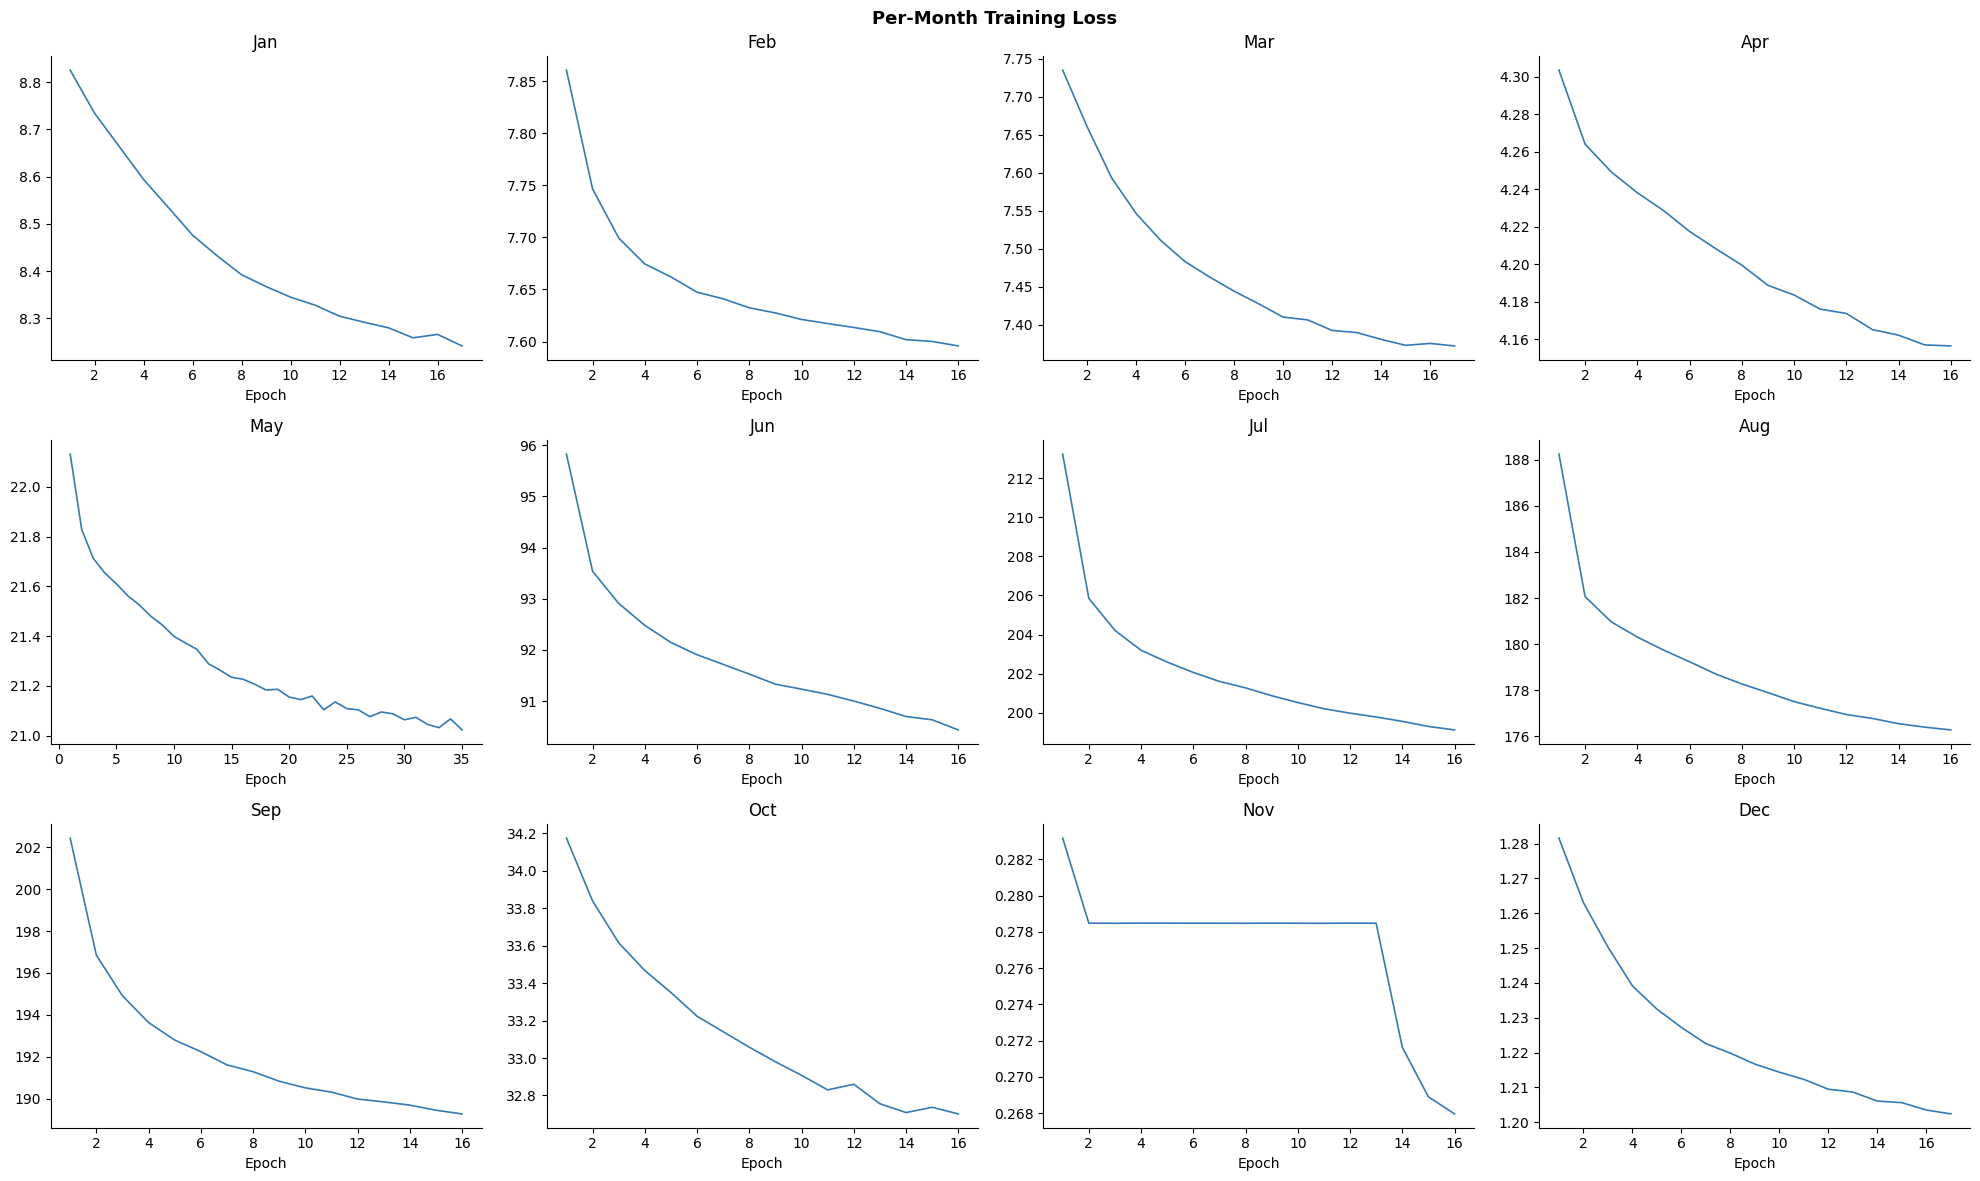

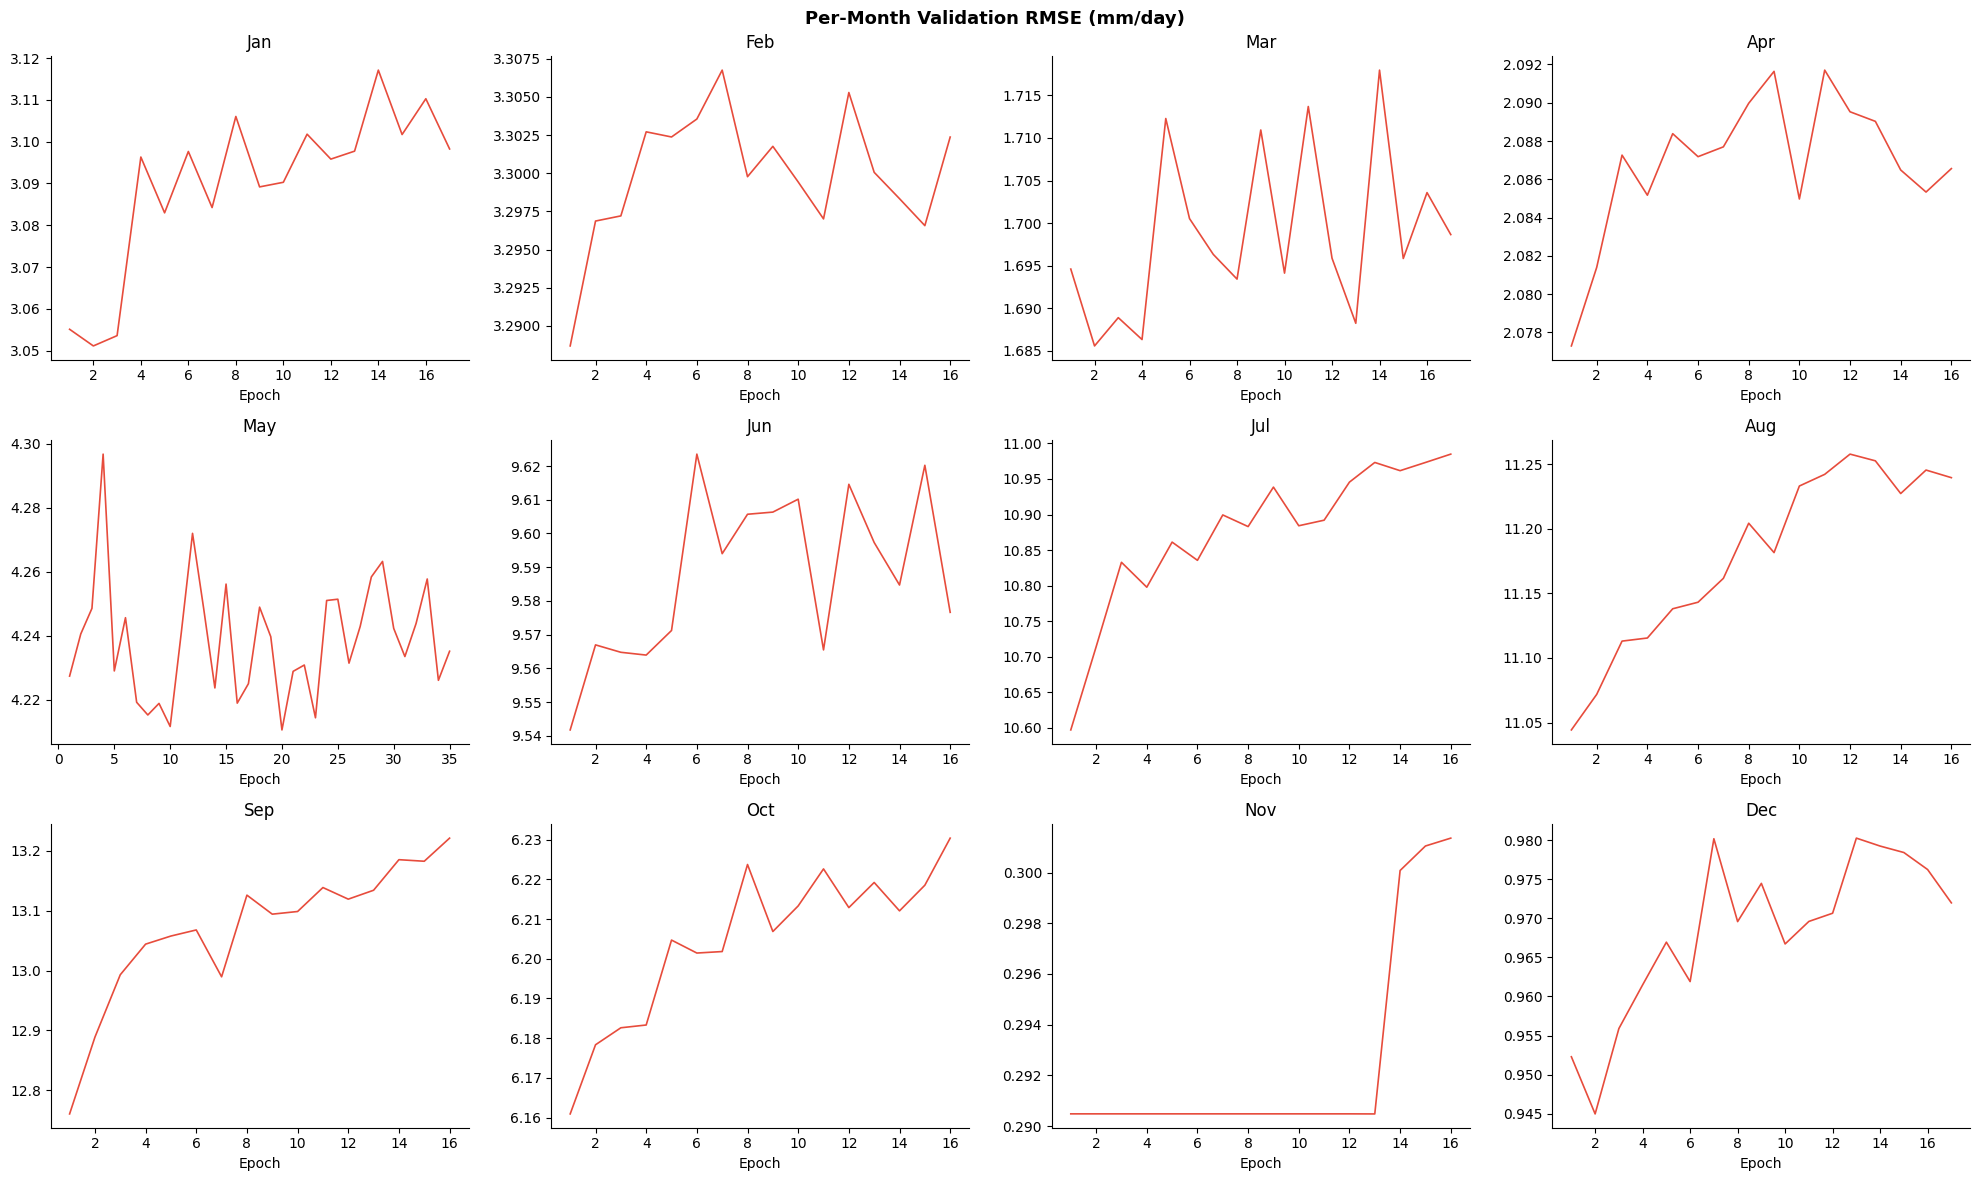

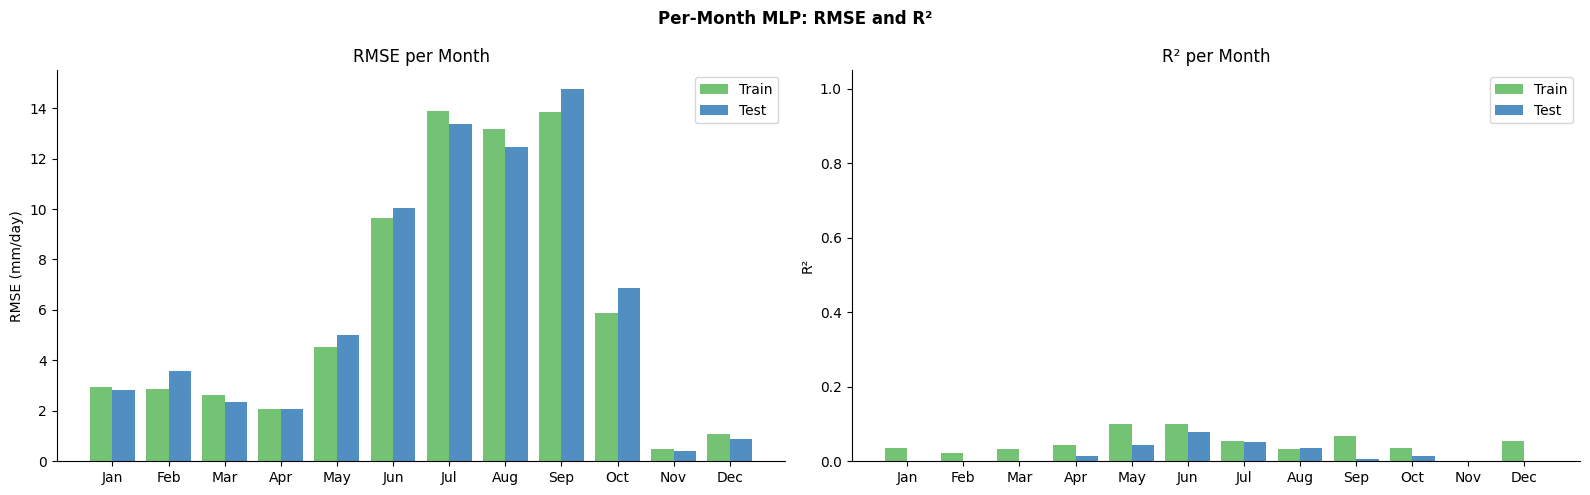


  COMPLETE → /kaggle/working/region_downscaling_output
Finished : 2026-06-15 14:50:13.445885


In [7]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell — QUICK EVALUATION (pooled metrics + training curves + bars)    ║
# ║  Pooled MAE, RMSE, R², KGE on bias-corrected output.                ║
# ║  Per-month training loss / val RMSE curves + Train vs Test bars.      ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ════════════════════════ PART 4 — EVALUATION ═════════════════════════
print("\n" + "="*60 + "\n  EVALUATION\n" + "="*60)
def kge(o, s):
    v = np.isfinite(o) & np.isfinite(s); o, s = o[v], s[v]
    if len(o) < 2: return np.nan
    r = np.corrcoef(o, s)[0, 1]
    return 1 - np.sqrt((r-1)**2 + (np.std(s)/(np.std(o)+1e-10)-1)**2
                       + (np.mean(s)/(np.mean(o)+1e-10)-1)**2)

def evaluate(bc_nc, years, label):
    ds = xr.open_dataset(bc_nc); obs_f, prd_f = [], []
    cell_rmse = []   # per-cell RMSE for an honest spatial-mean score
    for month in range(1, 13):
        obs = load_chirps_month(years, month)
        da  = ds["pr"].sel(time=ds["pr"].time.dt.month == month)
        if obs is None or len(da.time) == 0: continue
        nn_ = min(len(obs), len(da.time))
        o2 = obs[:nn_]; p2 = da.values[:nn_, ii_loc, jj_loc]
        obs_f.append(o2.ravel()); prd_f.append(p2.ravel())
        with np.errstate(invalid="ignore"):
            d = o2 - p2
            cell_rmse.append(np.sqrt(np.nanmean(d**2, axis=0)))
    ds.close()
    of = np.concatenate(obs_f); pf = np.concatenate(prd_f)
    v  = np.isfinite(of) & np.isfinite(pf) & (of >= 0) & (pf >= 0)
    cell_rmse = np.nanmean(np.vstack(cell_rmse), axis=0)
    print(f"\n  {label}\n  " + "─"*44)
    print(f"  N (pooled)        = {int(v.sum()):,}")
    print(f"  MAE  (pooled)     = {mean_absolute_error(of[v], pf[v]):.4f} mm/day")
    print(f"  RMSE (pooled)     = {np.sqrt(mean_squared_error(of[v], pf[v])):.4f} mm/day")
    print(f"  RMSE (cell-mean)  = {np.nanmean(cell_rmse):.4f} mm/day   ← honest spatial skill")
    print(f"  R²   (pooled)     = {r2_score(of[v], pf[v]):.4f}")
    print(f"  KGE  (pooled)     = {kge(of[v], pf[v]):.4f}", flush=True)

evaluate(BC_DAILY_TR, range(TRAIN_START, TRAIN_END+1), f"Training ({TRAIN_START}-{TRAIN_END})")
evaluate(BC_DAILY_TE, range(TEST_START,  TEST_END +1), f"Testing  ({TEST_START}-{TEST_END})")

# ════════════════════════ PART 5 — PLOTS ══════════════════════════════
def grid_plot(key, title, color, fname):
    fig, axes = plt.subplots(3, 4, figsize=(20, 12)); axes = axes.ravel()
    fig.suptitle(title, fontsize=13, fontweight="bold")
    for m in range(1, 13):
        ax = axes[m-1]
        if m in epoch_metrics and epoch_metrics[m].get(key):
            ax.plot(range(1, len(epoch_metrics[m][key])+1), epoch_metrics[m][key],
                    color=color, lw=1.2)
        ax.set_title(MONTH_NAMES[m-1]); ax.set_xlabel("Epoch")
        ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/{fname}", dpi=150, bbox_inches="tight"); plt.show()

grid_plot("train_loss", "Per-Month Training Loss", "#337ab7", "loss_curves.png")
grid_plot("val_rmse",   "Per-Month Validation RMSE (mm/day)", "#e74c3c", "val_rmse_curves.png")

months = [m for m in range(1, 13) if m in train_summary]
if months:
    x, w = np.arange(len(months)), 0.4
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("Per-Month MLP: RMSE and R²", fontsize=12, fontweight="bold")
    for ax, i_tr, i_te, ylab, ttl, ylim in [
        (ax1, 0, 2, "RMSE (mm/day)", "RMSE per Month", None),
        (ax2, 1, 3, "R²",            "R² per Month",   (0, 1.05))]:
        ax.bar(x-w/2, [train_summary[m][i_tr] for m in months], w, label="Train", color="#5cb85c", alpha=.85)
        ax.bar(x+w/2, [train_summary[m][i_te] for m in months], w, label="Test",  color="#337ab7", alpha=.85)
        ax.set_xticks(x); ax.set_xticklabels([MONTH_NAMES[m-1] for m in months])
        ax.set_ylabel(ylab); ax.set_title(ttl)
        if ylim: ax.set_ylim(*ylim)
        ax.legend(); ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/permonth_metrics.png", dpi=150, bbox_inches="tight"); plt.show()

print("\n" + "="*60 + f"\n  COMPLETE → {OUT_DIR}\n" + "="*60)
print(f"Finished : {pd.Timestamp.now()}", flush=True)


Computing all metrics in single low-RAM pass …
  Jan ✓    Feb ✓    Mar ✓    Apr ✓    May ✓    Jun ✓    Jul ✓    Aug ✓    Sep ✓    Oct ✓    Nov ✓    Dec ✓  
✓ single-pass collection done


  REVISED METRICS TABLE  (test 2005–2014)
Metric                                             Raw GCM      MLP downscaled   QM Bias-corrected
--------------------------------------------------------------------------------------------------

── MONTHLY ──────────────────────────────────────────────────────────
  Monthly RMSE Jan   (per-cell→avg)   23.5296   10.9351   14.5535
  Monthly RMSE Feb   (per-cell→avg)   36.8806   17.4857   20.3885
  Monthly RMSE Mar   (per-cell→avg)   40.5784   10.0474   16.4066
  Monthly RMSE Apr   (per-cell→avg)   17.2866   10.1374   11.5888
  Monthly RMSE May   (per-cell→avg)   46.1113   22.4132   32.4754
  Monthly RMSE Jun   (per-cell→avg)  143.3757   87.5079  105.1439
  Monthly RMSE Jul   (per-cell→avg)  246.7004   97.4927  114.0189
  Monthly RMSE Aug   (per-cell→avg)  18

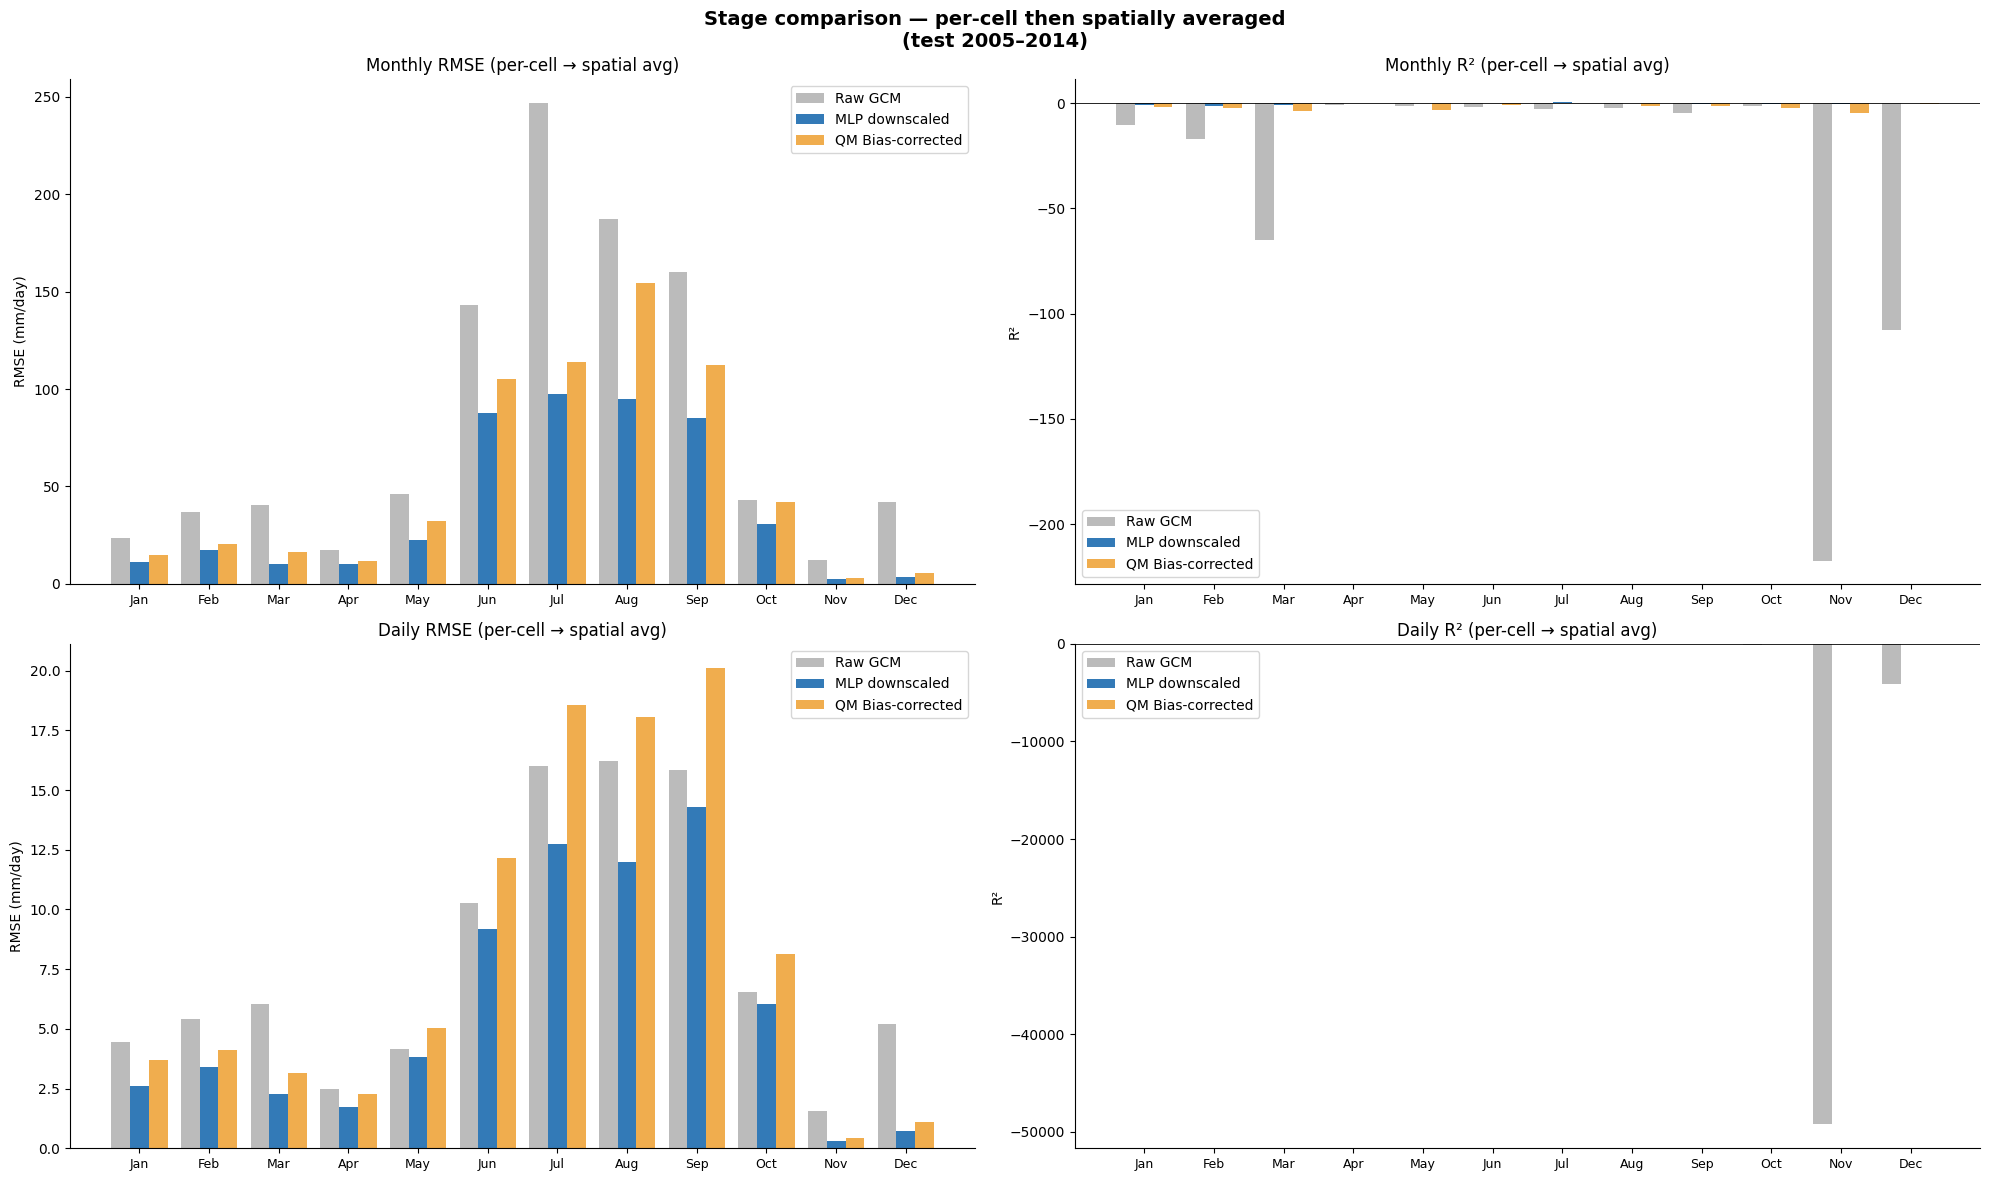

✅ Saved → stage_bars_percell_avg.png


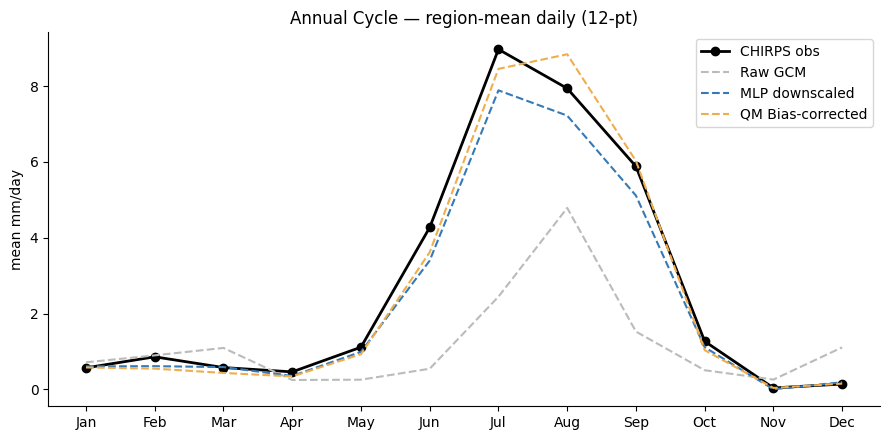

✅ Saved → annual_cycle.png


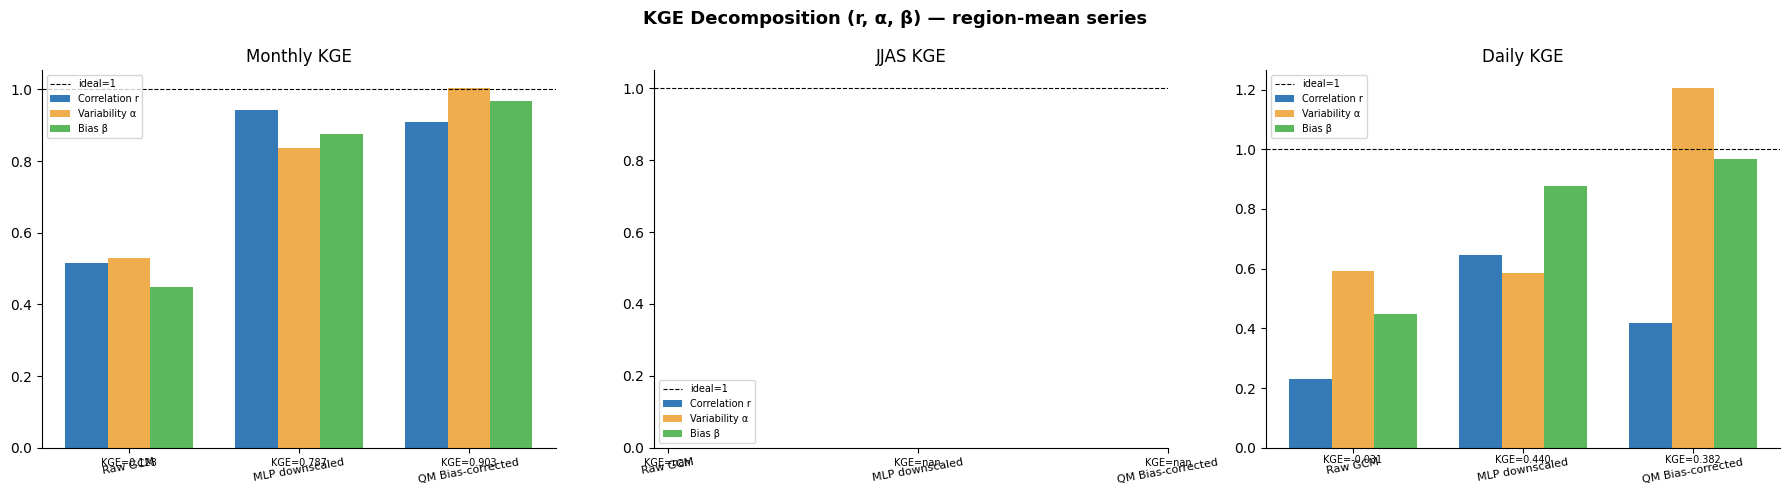

✅ Saved → kge_decomposition.png


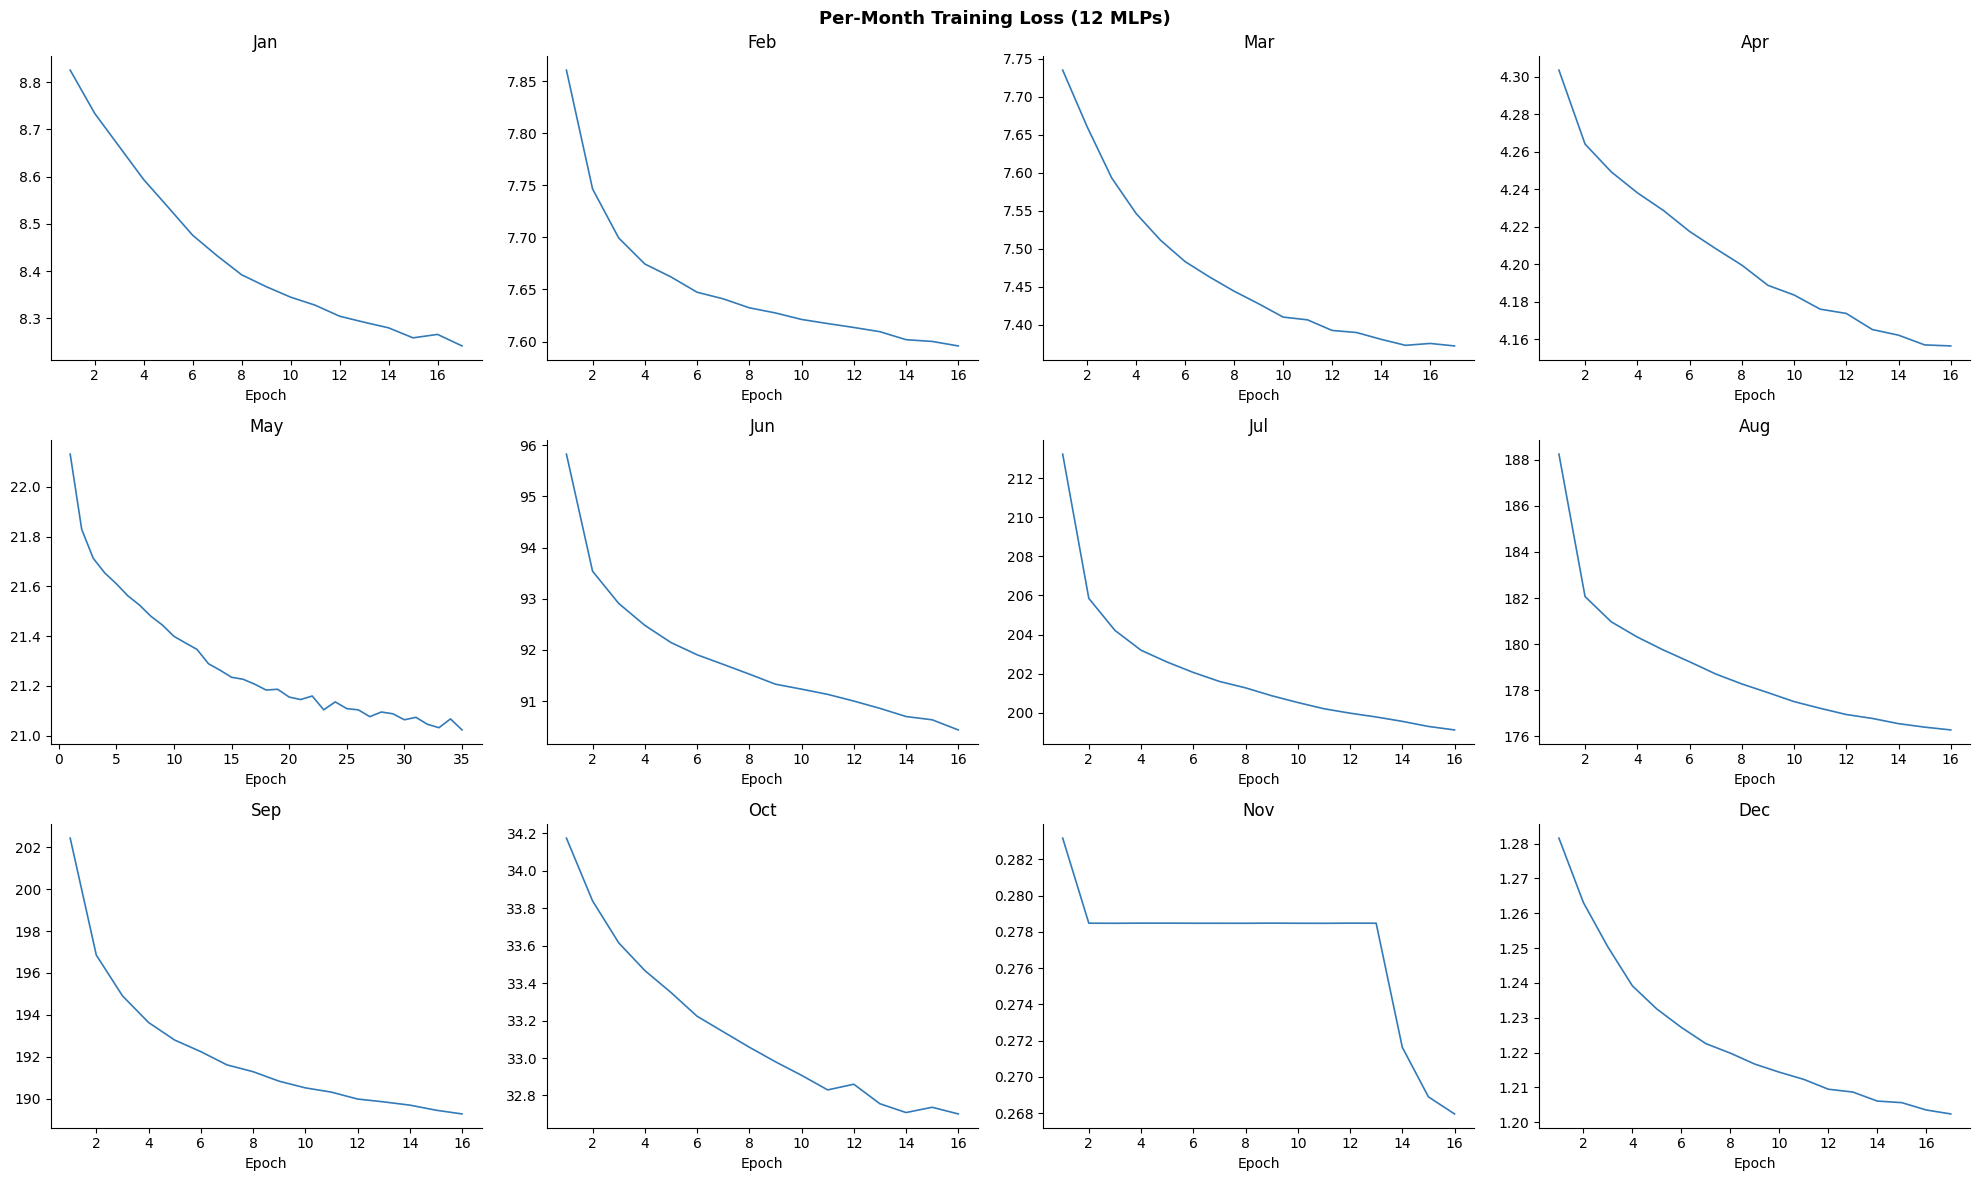

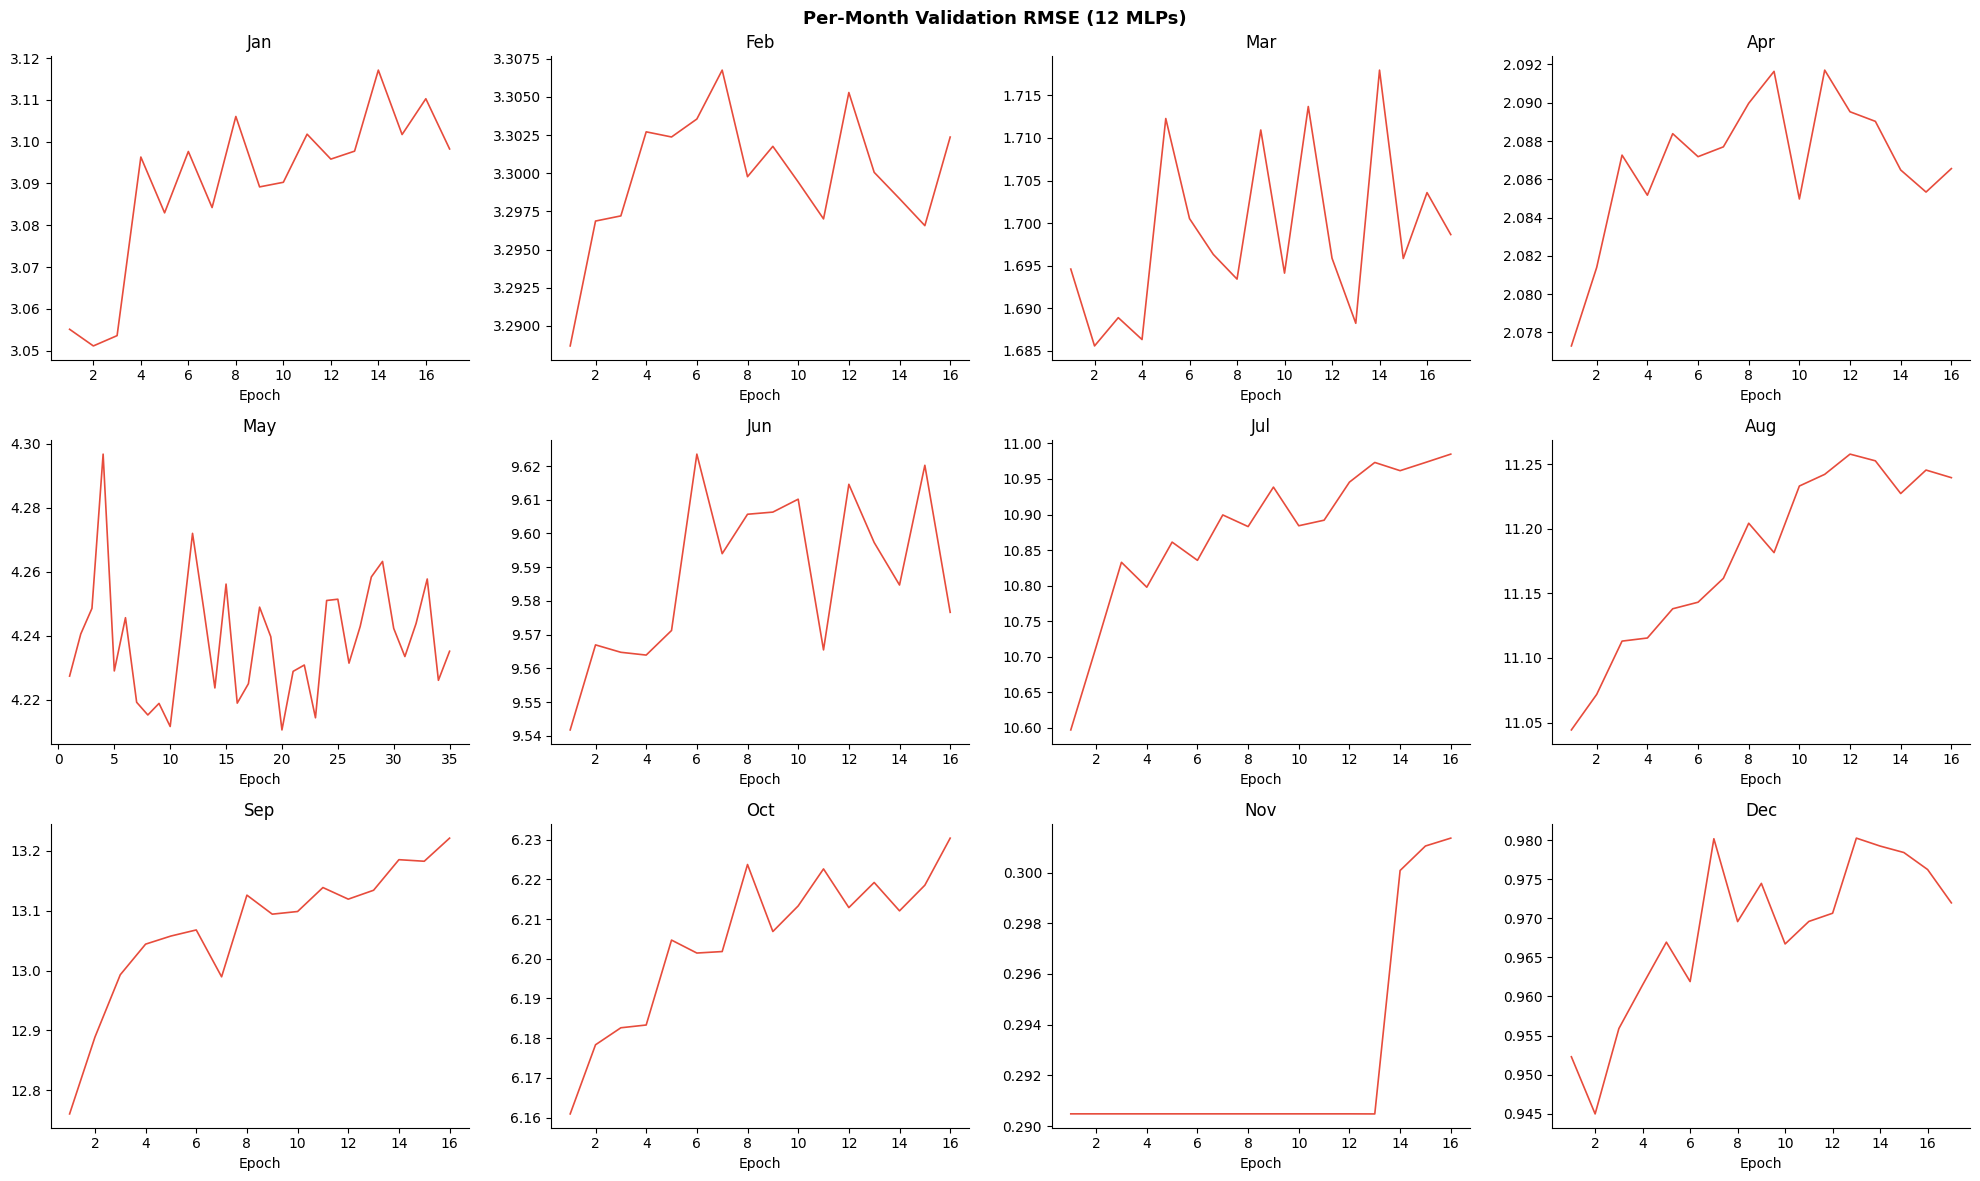

✅ Saved → loss_curves.png, val_rmse_curves.png


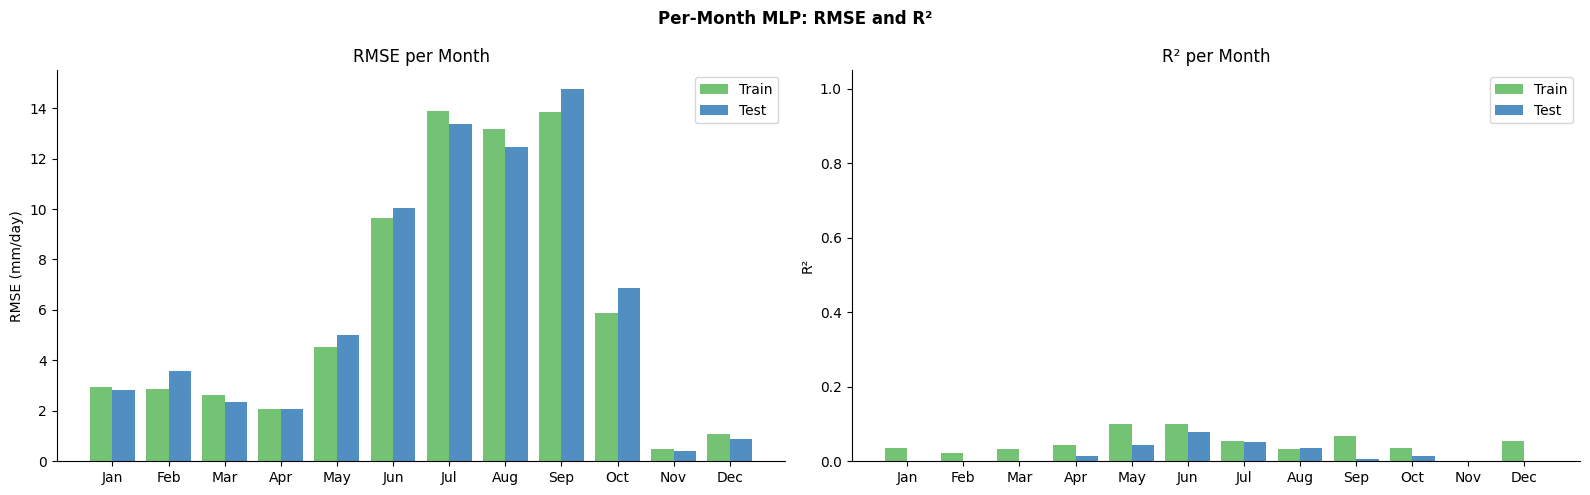

✅ Saved → permonth_metrics.png

✅ All metrics saved → /kaggle/working/region_downscaling_output/metrics_revised.csv

✅ Revised evaluation complete.


In [8]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 5 — EVALUATION (LOW-RAM version for 0.05° CHIRPS)               ║
# ║  Computes all metrics ON-THE-FLY per month — never stores full daily   ║
# ║  arrays.  Peak RAM ≈ 1 month of data (~400 MB) instead of ~5 GB.      ║
# ║  Adapted for 12 per-month MLP pipeline.                               ║
# ╚══════════════════════════════════════════════════════════════════════╝
import os, gc
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

gc.collect()

# ── (re)load QM TFs so this cell is standalone ──────────────────────────
if "tf_store" not in globals() or not tf_store:
    if os.path.exists(QM_TF_PATH):
        with np.load(QM_TF_PATH) as z:
            tf_store = {k: z[k] for k in z.files}
        print(f"✅ Loaded QM transfer functions for {len(tf_store)//2} month(s)")
    else:
        raise FileNotFoundError(f"QM transfer file not found: {QM_TF_PATH}")

EVAL_YEARS = range(TEST_START, TEST_END + 1)
EVAL_NC_MLP = MLP_DAILY_TE
EVAL_NC_BC  = BC_DAILY_TE

STAGES = ["raw", "mlp", "bias"]
LABELS = {"raw": "Raw GCM", "mlp": "MLP downscaled", "bias": "QM Bias-corrected"}
COLORS = {"raw": "#bbbbbb", "mlp": "#337ab7", "bias": "#f0ad4e"}

# ── metric helpers ───────────────────────────────────────────────────────
def _rmse_e(o, p): return float(np.sqrt(np.nanmean((o - p) ** 2)))
def _r2_e(o, p):
    ss = np.nansum((o - np.nanmean(o)) ** 2)
    return float(1 - np.nansum((o - p) ** 2) / ss) if ss > 0 else np.nan
def _corr_e(o, p):
    if o.size < 2 or np.nanstd(o) == 0 or np.nanstd(p) == 0: return np.nan
    return float(np.corrcoef(o, p)[0, 1])
def _kge_components_e(o, p):
    if o.size < 2: return np.nan, np.nan, np.nan, np.nan
    r = _corr_e(o, p)
    a = float(np.nanstd(p) / np.nanstd(o)) if np.nanstd(o) > 0 else np.nan
    b = float(np.nanmean(p) / np.nanmean(o)) if np.nanmean(o) != 0 else np.nan
    if any(np.isnan(v) for v in [r, a, b]): return np.nan, r, a, b
    kge = float(1 - np.sqrt((r - 1)**2 + (a - 1)**2 + (b - 1)**2))
    return kge, r, a, b

# ════════════════════════════════════════════════════════════════════════════
#  SINGLE PASS: compute ALL metrics per-month, store only scalars
# ════════════════════════════════════════════════════════════════════════════
print("Computing all metrics in single low-RAM pass …", flush=True)

# Scalar accumulators (tiny — 12 floats each)
monthly_rmse   = {s: np.full(12, np.nan) for s in STAGES}
monthly_r2     = {s: np.full(12, np.nan) for s in STAGES}
daily_rmse     = {s: np.full(12, np.nan) for s in STAGES}
daily_r2       = {s: np.full(12, np.nan) for s in STAGES}
clim_sum       = {s: np.zeros(n_region)  for s in STAGES}
obs_clim_sum   = np.zeros(n_region)
reg_mon_sum    = {s: np.zeros(12) for s in STAGES}
obs_reg_mon_sum = np.zeros(12)
reg_mon_cnt    = np.zeros(12)
total_days     = 0

# For KGE: region-mean series (only scalars per year-month — tiny)
mon_series     = {s: [] for s in STAGES}
obs_mon_list   = []
daily_reg_series = {s: [] for s in STAGES}
obs_daily_reg    = []

# Spatial clim maps: 12 × n_region (small — ~700 KB each)
obs_clim_maps  = {}
pred_clim_maps = {s: {} for s in STAGES}

dsm = xr.open_dataset(EVAL_NC_MLP)
dsb = xr.open_dataset(EVAL_NC_BC)

for month in range(1, 13):
    g, doy, dates = load_gcm_month(list(EVAL_YEARS), month)
    obs           = load_chirps_month(list(EVAL_YEARS), month)
    if g is None or obs is None:
        print(f"  {MONTH_NAMES[month-1]}: skip", flush=True); continue

    da_mlp = dsm["pr"].sel(time=dsm["pr"].time.dt.month == month)
    da_bc  = dsb["pr"].sel(time=dsb["pr"].time.dt.month == month)
    n = min(len(g), len(obs), len(da_mlp.time), len(da_bc.time))

    raw   = g[:n]
    mlp   = da_mlp.values[:n, ii_loc, jj_loc]
    bias  = da_bc.values[:n, ii_loc, jj_loc]
    obs_n = obs[:n]
    yrs   = dates[:n].year.values
    preds = {"raw": raw, "mlp": mlp, "bias": bias}

    obs_v = np.where(np.isfinite(obs_n) & (obs_n >= 0), obs_n, np.nan)

    # ── DAILY per-cell metrics (compute now, store only the 1 scalar) ──
    for s in STAGES:
        p_v = np.where(np.isfinite(preds[s]) & (preds[s] >= 0), preds[s], np.nan)
        # per-cell RMSE & R² across all days this month
        cell_rmse, cell_r2 = [], []
        for c in range(n_region):
            oc, pc = obs_v[:, c], p_v[:, c]
            v = np.isfinite(oc) & np.isfinite(pc)
            if v.sum() < 2: continue
            cell_rmse.append(_rmse_e(oc[v], pc[v]))
            cell_r2.append(_r2_e(oc[v], pc[v]))
        if cell_rmse:
            daily_rmse[s][month-1] = float(np.nanmean(cell_rmse))
            daily_r2[s][month-1]   = float(np.nanmean(cell_r2))

    # ── MONTHLY metrics (per-year totals → per-cell metric → avg) ──────
    for s in STAGES:
        yr_metrics_rmse, yr_metrics_r2 = [], []
        for yr in np.unique(yrs):
            sel = yrs == yr
            o_tot = np.nansum(obs_n[sel], axis=0)
            p_tot = np.nansum(preds[s][sel], axis=0)
            vv = np.isfinite(o_tot) & np.isfinite(p_tot)
            if vv.sum() == 0: continue
            yr_metrics_rmse.append(_rmse_e(o_tot[vv], p_tot[vv]))
            yr_metrics_r2.append(_r2_e(o_tot[vv], p_tot[vv]))
        if yr_metrics_rmse:
            monthly_rmse[s][month-1] = float(np.nanmean(yr_metrics_rmse))
            monthly_r2[s][month-1]   = float(np.nanmean(yr_metrics_r2))

    # ── region-mean monthly series (for KGE — one scalar per yr-month) ─
    for yr in np.unique(yrs):
        sel = yrs == yr
        obs_mon_list.append(float(np.nanmean(np.nansum(obs_n[sel], axis=0))))
        for s in STAGES:
            mon_series[s].append(float(np.nanmean(np.nansum(preds[s][sel], axis=0))))

    # ── region-mean daily series (for daily KGE — one scalar per day) ──
    obs_daily_reg.append(np.nanmean(obs_v, axis=1))
    for s in STAGES:
        daily_reg_series[s].append(np.nanmean(
            np.where(np.isfinite(preds[s]) & (preds[s]>=0), preds[s], np.nan), axis=1))

    # ── climatology accumulators ───────────────────────────────────────
    obs_clim_sum += np.nansum(obs_v, axis=0)
    total_days   += n
    for s in STAGES:
        clim_sum[s] += np.nansum(
            np.where(np.isfinite(preds[s]) & (preds[s]>=0), preds[s], np.nan), axis=0)

    # ── spatial climatology maps (one per month — small) ───────────────
    obs_clim_maps[month] = np.nanmean(obs_v, axis=0)
    for s in STAGES:
        pred_clim_maps[s][month] = np.nanmean(
            np.where(np.isfinite(preds[s]) & (preds[s]>=0), preds[s], np.nan), axis=0)

    # ── annual cycle accumulators ──────────────────────────────────────
    obs_reg_mon_sum[month-1] += float(np.nanmean(obs_v))
    reg_mon_cnt[month-1]     += 1
    for s in STAGES:
        reg_mon_sum[s][month-1] += float(
            np.nanmean(np.where(np.isfinite(preds[s]) & (preds[s]>=0), preds[s], np.nan)))

    # free this month's data
    del raw, mlp, bias, obs_n, obs_v, preds, da_mlp, da_bc
    gc.collect()
    print(f"  {MONTH_NAMES[month-1]} ✓", end="  ", flush=True)

dsm.close(); dsb.close(); gc.collect()
print("\n✓ single-pass collection done\n")

# ── derived scalars ──────────────────────────────────────────────────────
obs_clim     = obs_clim_sum / max(total_days, 1)
clim_percell = {s: clim_sum[s] / max(total_days, 1) for s in STAGES}
cnt = np.where(reg_mon_cnt == 0, 1, reg_mon_cnt)
obs_reg_mon  = obs_reg_mon_sum / cnt
reg_mon_mean = {s: reg_mon_sum[s] / cnt for s in STAGES}

# Monthly KGE
obs_mon_arr = np.array(obs_mon_list)
monthly_kge = {}
for s in STAGES:
    kge, r, a, b = _kge_components_e(obs_mon_arr, np.array(mon_series[s]))
    monthly_kge[s] = {"KGE": kge, "r": r, "alpha": a, "beta": b}

# Spatial climatology corr (12 maps concatenated)
valid_months = sorted(obs_clim_maps.keys())
spatial_clim_corr = {}
obs_vec = np.concatenate([obs_clim_maps[m] for m in valid_months])
for s in STAGES:
    p_vec = np.concatenate([pred_clim_maps[s][m] for m in valid_months if m in pred_clim_maps[s]])
    o_vec = np.concatenate([obs_clim_maps[m] for m in valid_months if m in pred_clim_maps[s]])
    v = np.isfinite(o_vec) & np.isfinite(p_vec)
    spatial_clim_corr[s] = _corr_e(o_vec[v], p_vec[v])

# Annual cycle corr
annual_cycle_corr = {s: _corr_e(obs_reg_mon, reg_mon_mean[s]) for s in STAGES}

# Annual pattern corr
annual_pattern_corr = {}
v_ap = np.isfinite(obs_clim)
for s in STAGES:
    vv = v_ap & np.isfinite(clim_percell[s])
    annual_pattern_corr[s] = _corr_e(obs_clim[vv], clim_percell[s][vv])

# JJAS KGE & R²
jjas_idx = []
k = 0
for month in range(1, 13):
    g, _, _ = load_gcm_month(list(EVAL_YEARS), month)
    obs     = load_chirps_month(list(EVAL_YEARS), month)
    if g is None or obs is None: continue
    n2 = min(len(g), len(obs))
    if month in [6, 7, 8, 9]:
        jjas_idx.extend(range(k, k + n2))
    k += n2

jjas_kge, jjas_r2 = {}, {}
for s in STAGES:
    ms = np.array(mon_series[s])
    if not jjas_idx or len(ms) == 0:
        jjas_kge[s] = {"KGE": np.nan, "r": np.nan, "alpha": np.nan, "beta": np.nan}
        jjas_r2[s] = np.nan; continue
    vi = [i for i in jjas_idx if i < len(ms) and i < len(obs_mon_arr)]
    o_j, p_j = obs_mon_arr[vi], ms[vi]
    vm = np.isfinite(o_j) & np.isfinite(p_j)
    kge, r, a, b = _kge_components_e(o_j[vm], p_j[vm])
    jjas_kge[s] = {"KGE": kge, "r": r, "alpha": a, "beta": b}
    jjas_r2[s] = _r2_e(o_j[vm], p_j[vm])

# Daily KGE
obs_d = np.concatenate(obs_daily_reg)
daily_kge = {}
for s in STAGES:
    pd_arr = np.concatenate(daily_reg_series[s])
    kge, r, a, b = _kge_components_e(obs_d, pd_arr)
    daily_kge[s] = {"KGE": kge, "r": r, "alpha": a, "beta": b}

# ════════════════════════════════════════════════════════════════════════════
# SECTION 7 ── PRINT FULL METRICS TABLE
# ════════════════════════════════════════════════════════════════════════════
yr0, yr1 = EVAL_YEARS.start, EVAL_YEARS.stop - 1
print(f"\n{'='*72}")
print(f"  REVISED METRICS TABLE  (test {yr0}–{yr1})")
print(f"{'='*72}")

def _fmt(v): return f"{v:8.4f}" if np.isfinite(v) else "     nan"

header = f"{'Metric':<38}" + "".join(f"  {LABELS[s]:>18}" for s in STAGES)
print(header); print("-"*len(header))

print("\n── MONTHLY ──────────────────────────────────────────────────────────")
for m in range(1, 13):
    print(f"  Monthly RMSE {MONTH_NAMES[m-1]:<4}  (per-cell→avg)  "
          + "  ".join([_fmt(monthly_rmse[s][m-1]) for s in STAGES]))
for m in range(1, 13):
    print(f"  Monthly R²   {MONTH_NAMES[m-1]:<4}  (per-cell→avg)  "
          + "  ".join([_fmt(monthly_r2[s][m-1]) for s in STAGES]))
print(f"\n  {'Metric':<38}" + "".join(f"  {LABELS[s]:>18}" for s in STAGES))
print("  " + "-"*78)
for key in ["KGE", "r", "alpha", "beta"]:
    row = [monthly_kge[s][key] for s in STAGES]
    print(f"  Monthly {key:<30}" + "".join([f"  {_fmt(v):>18}" for v in row]))

print("\n── SPATIAL & ANNUAL CYCLE ────────────────────────────────────────────")
print(f"  {'Spatial Climatology Corr (12 maps)':<38}" +
      "".join(f"  {_fmt(spatial_clim_corr[s]):>18}" for s in STAGES))
print(f"  {'Annual Cycle Corr (12-pt region mean)':<38}" +
      "".join(f"  {_fmt(annual_cycle_corr[s]):>18}" for s in STAGES))
print(f"  {'Annual Pattern Corr (per-cell mean)':<38}" +
      "".join(f"  {_fmt(annual_pattern_corr[s]):>18}" for s in STAGES))

print("\n── JJAS ──────────────────────────────────────────────────────────────")
for key in ["KGE", "r", "alpha", "beta"]:
    row = [jjas_kge[s][key] for s in STAGES]
    print(f"  JJAS {key:<33}" + "".join([f"  {_fmt(v):>18}" for v in row]))
print(f"  {'JJAS R² (region-mean series)':<38}" +
      "".join(f"  {_fmt(jjas_r2[s]):>18}" for s in STAGES))

print("\n── DAILY ─────────────────────────────────────────────────────────────")
for m in range(1, 13):
    print(f"  Daily RMSE {MONTH_NAMES[m-1]:<4}  (per-cell→avg)  "
          + "  ".join([_fmt(daily_rmse[s][m-1]) for s in STAGES]))
for m in range(1, 13):
    print(f"  Daily R²   {MONTH_NAMES[m-1]:<4}  (per-cell→avg)  "
          + "  ".join([_fmt(daily_r2[s][m-1]) for s in STAGES]))
for key in ["KGE", "r", "alpha", "beta"]:
    row = [daily_kge[s][key] for s in STAGES]
    print(f"  Daily {key:<33}" + "".join([f"  {_fmt(v):>18}" for v in row]))

# ════════════════════════════════════════════════════════════════════════════
# SECTION 8 ── STAGE BAR CHARTS
# ════════════════════════════════════════════════════════════════════════════
x = np.arange(12); w = 0.27
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle(f"Stage comparison — per-cell then spatially averaged\n"
             f"(test {yr0}–{yr1})", fontsize=14, fontweight="bold")

ax = axes[0, 0]
for i, s in enumerate(STAGES):
    ax.bar(x + (i-1)*w, monthly_rmse[s], w, label=LABELS[s], color=COLORS[s])
ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES, fontsize=9)
ax.set_title("Monthly RMSE (per-cell → spatial avg)"); ax.set_ylabel("RMSE (mm/day)")
ax.legend(); ax.spines[["top","right"]].set_visible(False); ax.axhline(0, color="k", lw=.6)

ax = axes[0, 1]
for i, s in enumerate(STAGES):
    ax.bar(x + (i-1)*w, monthly_r2[s], w, label=LABELS[s], color=COLORS[s])
ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES, fontsize=9)
ax.set_title("Monthly R² (per-cell → spatial avg)"); ax.set_ylabel("R²")
ax.legend(); ax.spines[["top","right"]].set_visible(False); ax.axhline(0, color="k", lw=.6)

ax = axes[1, 0]
for i, s in enumerate(STAGES):
    ax.bar(x + (i-1)*w, daily_rmse[s], w, label=LABELS[s], color=COLORS[s])
ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES, fontsize=9)
ax.set_title("Daily RMSE (per-cell → spatial avg)"); ax.set_ylabel("RMSE (mm/day)")
ax.legend(); ax.spines[["top","right"]].set_visible(False); ax.axhline(0, color="k", lw=.6)

ax = axes[1, 1]
for i, s in enumerate(STAGES):
    ax.bar(x + (i-1)*w, daily_r2[s], w, label=LABELS[s], color=COLORS[s])
ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES, fontsize=9)
ax.set_title("Daily R² (per-cell → spatial avg)"); ax.set_ylabel("R²")
ax.legend(); ax.spines[["top","right"]].set_visible(False); ax.axhline(0, color="k", lw=.6)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/stage_bars_percell_avg.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → stage_bars_percell_avg.png")

# ════════════════════════════════════════════════════════════════════════════
# SECTION 9 ── ANNUAL CYCLE LINE PLOT
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(range(1, 13), obs_reg_mon, "k-o", lw=2, label="CHIRPS obs")
for s in STAGES:
    ax.plot(range(1, 13), reg_mon_mean[s], "--", color=COLORS[s], label=LABELS[s])
ax.set_xticks(range(1, 13)); ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel("mean mm/day"); ax.set_title("Annual Cycle — region-mean daily (12-pt)")
ax.legend(); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/annual_cycle.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → annual_cycle.png")

# ════════════════════════════════════════════════════════════════════════════
# SECTION 10 ── KGE DECOMPOSITION PLOT
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("KGE Decomposition (r, α, β) — region-mean series", fontsize=13, fontweight="bold")
kge_sets = [("Monthly KGE", monthly_kge), ("JJAS KGE", jjas_kge), ("Daily KGE", daily_kge)]
comp_labels = {"r": "Correlation r", "alpha": "Variability α", "beta": "Bias β"}
comp_colors = {"r": "#337ab7", "alpha": "#f0ad4e", "beta": "#5cb85c"}

for ax, (title, kge_dict) in zip(axes, kge_sets):
    xs = np.arange(len(STAGES)); bw = 0.25
    for j, comp in enumerate(["r", "alpha", "beta"]):
        vals = [kge_dict[s][comp] for s in STAGES]
        ax.bar(xs + (j-1)*bw, vals, bw, label=comp_labels[comp], color=comp_colors[comp])
    ax.axhline(1, color="k", lw=0.8, ls="--", label="ideal=1")
    ax.axhline(0, color="k", lw=0.4)
    ax.set_xticks(xs); ax.set_xticklabels([LABELS[s] for s in STAGES], fontsize=8, rotation=10)
    ax.set_title(title); ax.legend(fontsize=7)
    ax.spines[["top","right"]].set_visible(False)
    for j2, s in enumerate(STAGES):
        kge_v = kge_dict[s]["KGE"]
        ax.text(j2, ax.get_ylim()[0]*0.97 if ax.get_ylim()[0] < 0 else -0.05,
                f"KGE={kge_v:.3f}", ha="center", fontsize=7, color="black")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/kge_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → kge_decomposition.png")

# ════════════════════════════════════════════════════════════════════════════
# SECTION 11 ── TRAINING CURVES  (adapted for 12 per-month MLPs)
# ════════════════════════════════════════════════════════════════════════════
# Try in-memory epoch_metrics first (available if Cell 4 just ran),
# otherwise load per-month CSVs from disk.
if "epoch_metrics" not in globals() or not epoch_metrics:
    epoch_metrics = {}
    for month in range(1, 13):
        mstr = f"m{month:02d}"
        ep_csv = os.path.join(OUT_DIR, f"epoch_metrics_{mstr}.csv")
        if os.path.exists(ep_csv):
            d = pd.read_csv(ep_csv)
            epoch_metrics[month] = {
                "train_loss": d["train_loss"].tolist(),
                "val_rmse":   d["val_rmse"].dropna().tolist(),
            }
    if epoch_metrics:
        print(f"✅ Loaded epoch metrics from CSV for {len(epoch_metrics)} month(s)")

if epoch_metrics:
    # 3×4 grid: per-month training loss
    fig, axes = plt.subplots(3, 4, figsize=(20, 12)); axes_flat = axes.ravel()
    fig.suptitle("Per-Month Training Loss (12 MLPs)", fontsize=13, fontweight="bold")
    for m in range(1, 13):
        ax = axes_flat[m-1]
        if m in epoch_metrics and epoch_metrics[m].get("train_loss"):
            vals = epoch_metrics[m]["train_loss"]
            ax.plot(range(1, len(vals)+1), vals, color="#337ab7", lw=1.2)
        ax.set_title(MONTH_NAMES[m-1]); ax.set_xlabel("Epoch")
        ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/loss_curves.png", dpi=150, bbox_inches="tight"); plt.show()

    # 3×4 grid: per-month val RMSE
    fig, axes = plt.subplots(3, 4, figsize=(20, 12)); axes_flat = axes.ravel()
    fig.suptitle("Per-Month Validation RMSE (12 MLPs)", fontsize=13, fontweight="bold")
    for m in range(1, 13):
        ax = axes_flat[m-1]
        if m in epoch_metrics and epoch_metrics[m].get("val_rmse"):
            vals = epoch_metrics[m]["val_rmse"]
            ax.plot(range(1, len(vals)+1), vals, color="#e74c3c", lw=1.2)
        ax.set_title(MONTH_NAMES[m-1]); ax.set_xlabel("Epoch")
        ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/val_rmse_curves.png", dpi=150, bbox_inches="tight"); plt.show()
    print("✅ Saved → loss_curves.png, val_rmse_curves.png")

    # Summary bar: per-month Train/Test RMSE & R² (from train_summary if available)
    if "train_summary" in globals() and train_summary:
        months = [m for m in range(1, 13) if m in train_summary]
        if months:
            x2, w2 = np.arange(len(months)), 0.4
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
            fig.suptitle("Per-Month MLP: RMSE and R²", fontsize=12, fontweight="bold")
            for ax, i_tr, i_te, ylab, ttl, ylim in [
                (ax1, 0, 2, "RMSE (mm/day)", "RMSE per Month", None),
                (ax2, 1, 3, "R²",            "R² per Month",   (0, 1.05))]:
                ax.bar(x2-w2/2, [train_summary[m][i_tr] for m in months], w2,
                       label="Train", color="#5cb85c", alpha=.85)
                ax.bar(x2+w2/2, [train_summary[m][i_te] for m in months], w2,
                       label="Test",  color="#337ab7", alpha=.85)
                ax.set_xticks(x2); ax.set_xticklabels([MONTH_NAMES[m-1] for m in months])
                ax.set_ylabel(ylab); ax.set_title(ttl)
                if ylim: ax.set_ylim(*ylim)
                ax.legend(); ax.spines[["top","right"]].set_visible(False)
            plt.tight_layout()
            plt.savefig(f"{OUT_DIR}/permonth_metrics.png", dpi=150, bbox_inches="tight"); plt.show()
            print("✅ Saved → permonth_metrics.png")
else:
    print("ℹ No epoch metrics found — skipping training curves")

# ════════════════════════════════════════════════════════════════════════════
# SECTION 12 ── SAVE METRICS TO CSV
# ════════════════════════════════════════════════════════════════════════════
rows = []
for m in range(1, 13):
    rows.append({"metric": f"Monthly RMSE {MONTH_NAMES[m-1]} (per-cell→avg)", "method": "per-cell→spatial avg",
                 **{LABELS[s]: monthly_rmse[s][m-1] for s in STAGES}})
for m in range(1, 13):
    rows.append({"metric": f"Monthly R² {MONTH_NAMES[m-1]} (per-cell→avg)", "method": "per-cell→spatial avg",
                 **{LABELS[s]: monthly_r2[s][m-1] for s in STAGES}})
for key in ["KGE", "r", "alpha", "beta"]:
    rows.append({"metric": f"Monthly {key} (region-mean series)", "method": "region-mean",
                 **{LABELS[s]: monthly_kge[s][key] for s in STAGES}})
rows.append({"metric": "Spatial Climatology Corr (12 maps concat)", "method": "per-cell spatial",
             **{LABELS[s]: spatial_clim_corr[s] for s in STAGES}})
rows.append({"metric": "Annual Cycle Corr (12-pt region mean)", "method": "region-mean",
             **{LABELS[s]: annual_cycle_corr[s] for s in STAGES}})
rows.append({"metric": "Annual Pattern Corr (per-cell annual mean)", "method": "per-cell spatial",
             **{LABELS[s]: annual_pattern_corr[s] for s in STAGES}})
for key in ["KGE", "r", "alpha", "beta"]:
    rows.append({"metric": f"JJAS {key} (region-mean series)", "method": "region-mean",
                 **{LABELS[s]: jjas_kge[s][key] for s in STAGES}})
rows.append({"metric": "JJAS R² (region-mean JJAS series)", "method": "region-mean",
             **{LABELS[s]: jjas_r2[s] for s in STAGES}})
for m in range(1, 13):
    rows.append({"metric": f"Daily RMSE {MONTH_NAMES[m-1]} (per-cell→avg)", "method": "per-cell→spatial avg",
                 **{LABELS[s]: daily_rmse[s][m-1] for s in STAGES}})
for m in range(1, 13):
    rows.append({"metric": f"Daily R² {MONTH_NAMES[m-1]} (per-cell→avg)", "method": "per-cell→spatial avg",
                 **{LABELS[s]: daily_r2[s][m-1] for s in STAGES}})
for key in ["KGE", "r", "alpha", "beta"]:
    rows.append({"metric": f"Daily {key} (region-mean daily series)", "method": "region-mean",
                 **{LABELS[s]: daily_kge[s][key] for s in STAGES}})

df_metrics = pd.DataFrame(rows)
out_csv = f"{OUT_DIR}/metrics_revised.csv"
df_metrics.to_csv(out_csv, index=False)
print(f"\n✅ All metrics saved → {out_csv}")
print("\n✅ Revised evaluation complete.")


In [9]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  KAGGLE Cell 5 — zip everything for download                         ║
# ╚══════════════════════════════════════════════════════════════════════╝
import shutil
zip_path = shutil.make_archive("/kaggle/working/region_results", "zip", OUT_DIR)
print(f"✅ {zip_path}  ({os.path.getsize(zip_path)/1e6:.1f} MB)")
print("Download it from the notebook's Output panel (right side) →")
print("then upload bc_daily_*.nc etc. back to your Google Drive for analysis.")
print("\nTo resume on next kernel restart:")
print("  1. Download this zip from the Output panel →")
print("  2. Extract and upload the region_downscaling_output/ folder")
print("     back into your Kaggle dataset")
print("  3. On next run, Cell 4 will auto-skip already-trained months")


✅ /kaggle/working/region_results.zip  (665.5 MB)
Download it from the notebook's Output panel (right side) →
then upload bc_daily_*.nc etc. back to your Google Drive for analysis.

To resume on next kernel restart:
  1. Download this zip from the Output panel →
  2. Extract and upload the region_downscaling_output/ folder
     back into your Kaggle dataset
  3. On next run, Cell 4 will auto-skip already-trained months
